# Geometry — part 2 of 5

This notebook was automatically split from a larger notebook.

Found 512 saved t-SNE / UMAP files
Using max_points_per_file=4000, k_neighbors=40
[1/512] tsne_embedding_C3.npy | method=tsne | source_dim=3 | channel=C3 | full=10000 | used=4000
[2/512] tsne_embedding_C4.npy | method=tsne | source_dim=3 | channel=C4 | full=10000 | used=4000
[3/512] tsne_embedding_CP1.npy | method=tsne | source_dim=3 | channel=CP1 | full=10000 | used=4000
[4/512] tsne_embedding_CP2.npy | method=tsne | source_dim=3 | channel=CP2 | full=10000 | used=4000
[5/512] tsne_embedding_CP5.npy | method=tsne | source_dim=3 | channel=CP5 | full=10000 | used=4000
[6/512] tsne_embedding_CP6.npy | method=tsne | source_dim=3 | channel=CP6 | full=10000 | used=4000
[7/512] tsne_embedding_Cz.npy | method=tsne | source_dim=3 | channel=Cz | full=10000 | used=4000
[8/512] tsne_embedding_F3.npy | method=tsne | source_dim=3 | channel=F3 | full=10000 | used=4000
[9/512] tsne_embedding_F4.npy | method=tsne | source_dim=3 | channel=F4 | full=10000 | used=4000
[10/512] tsne_embedding_F7.npy | meth

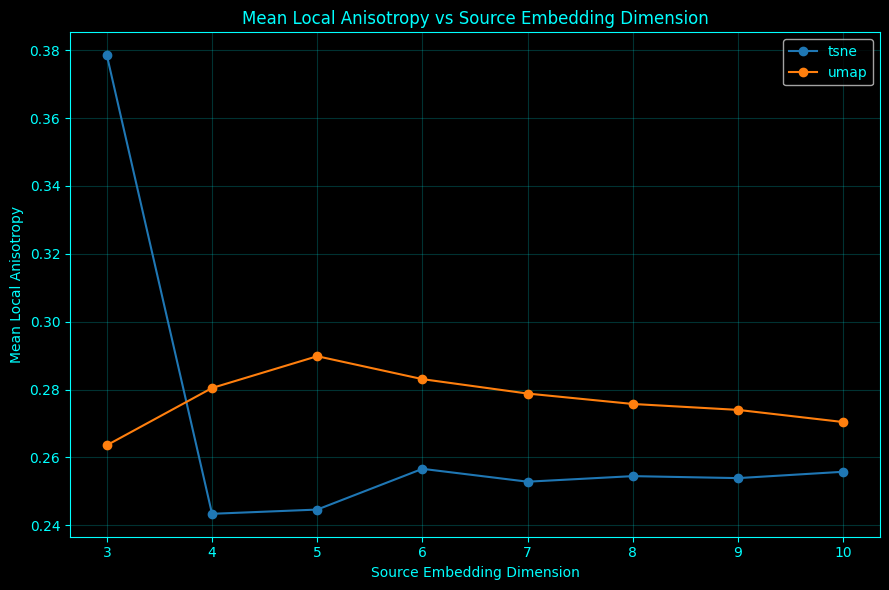

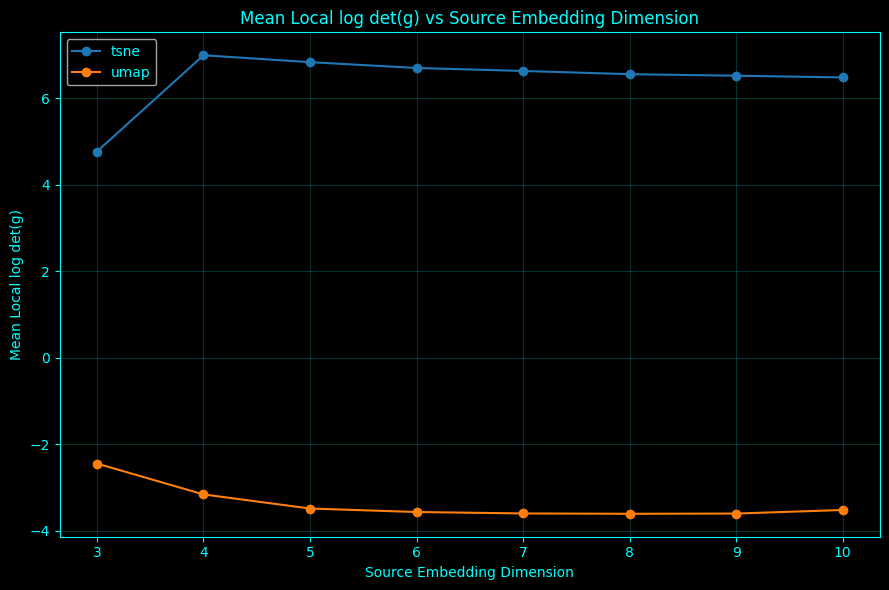

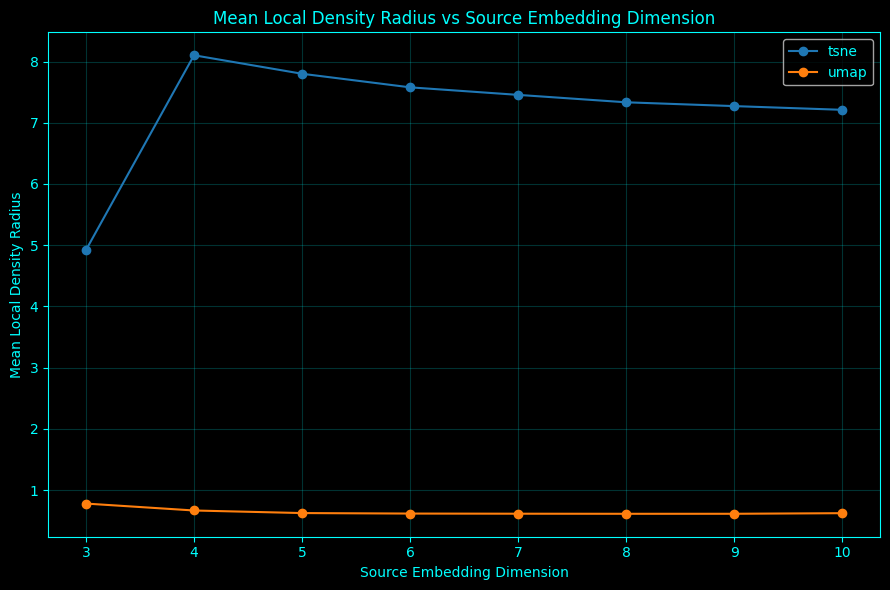

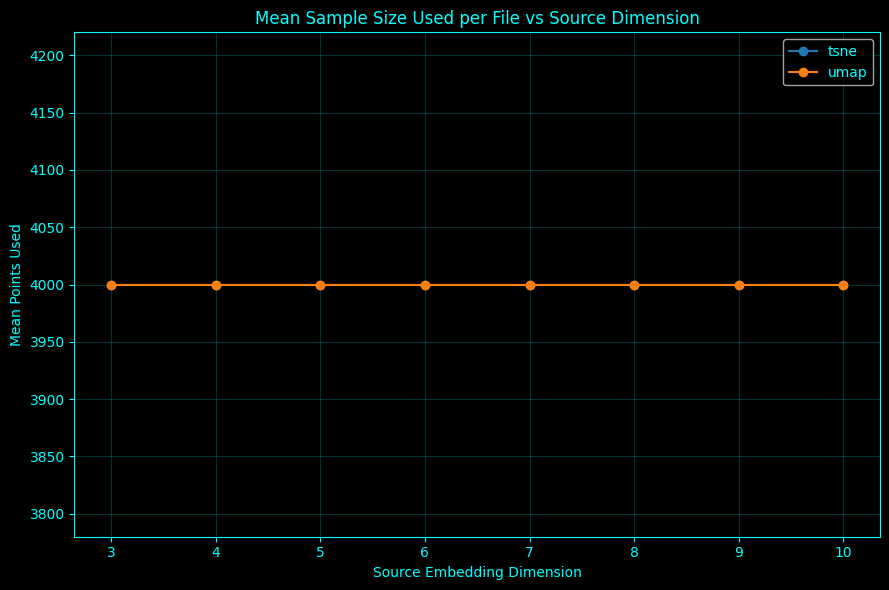

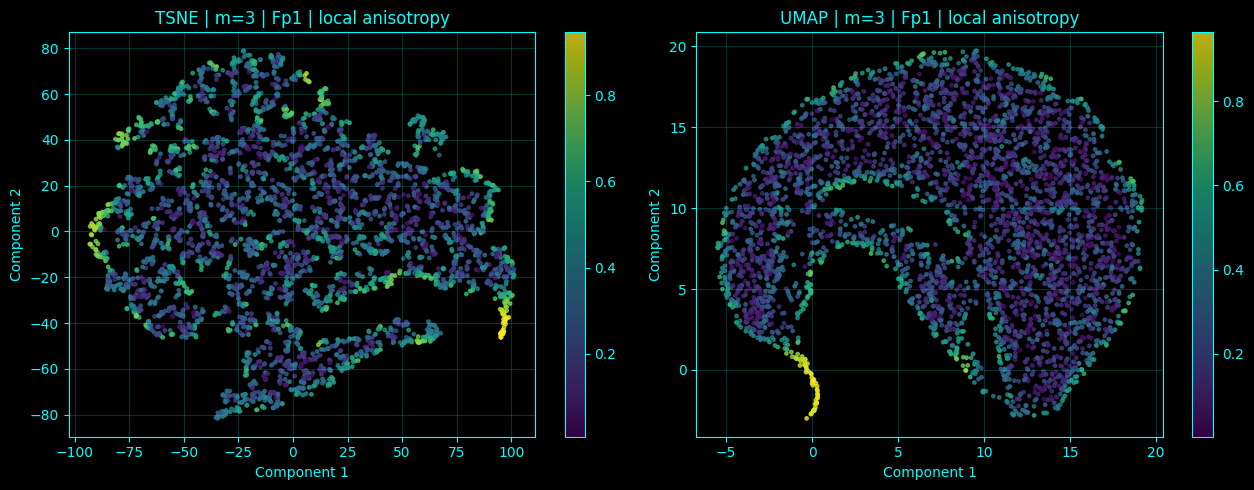

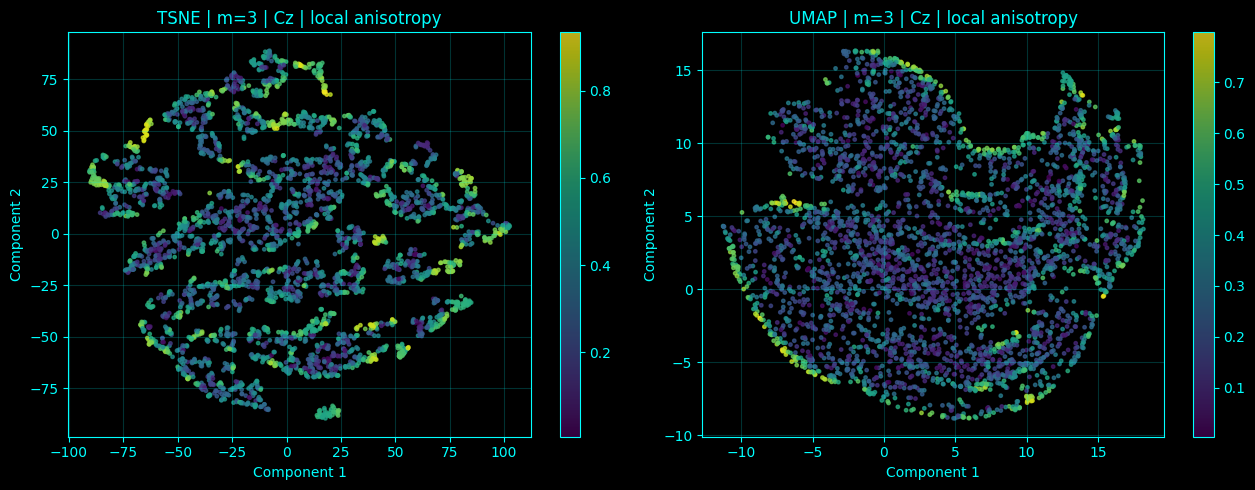

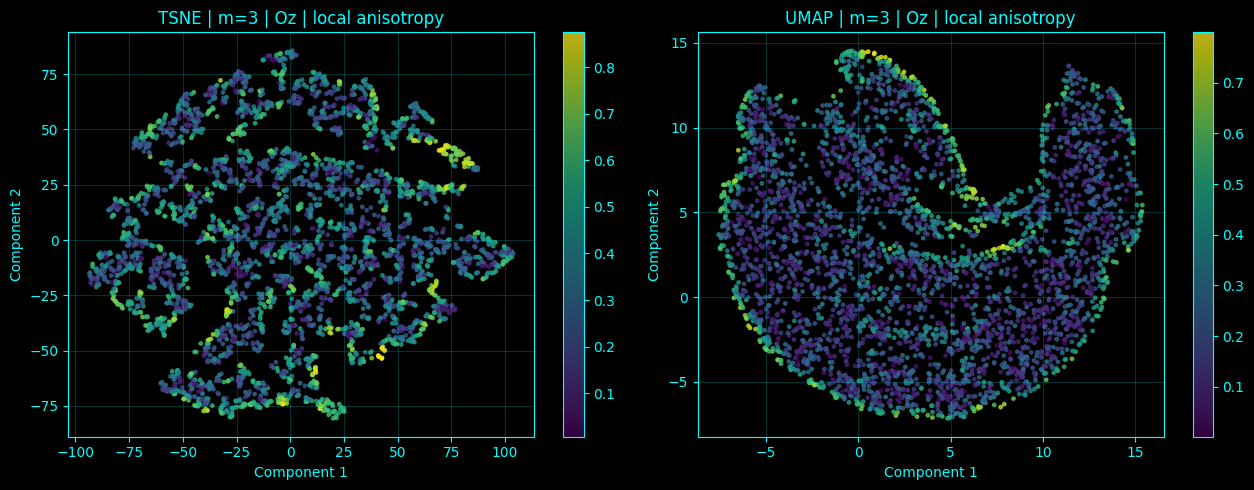

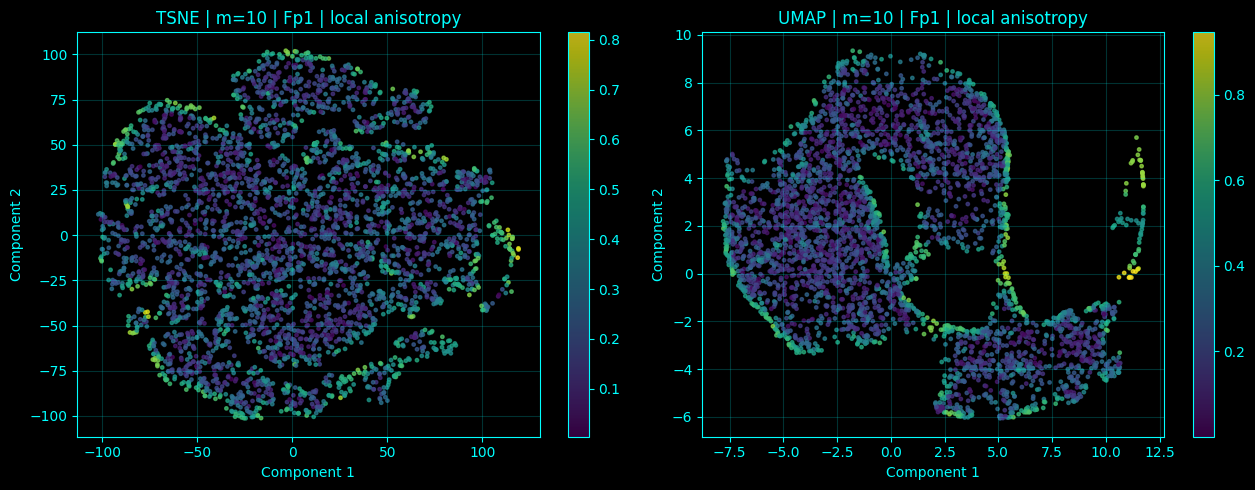

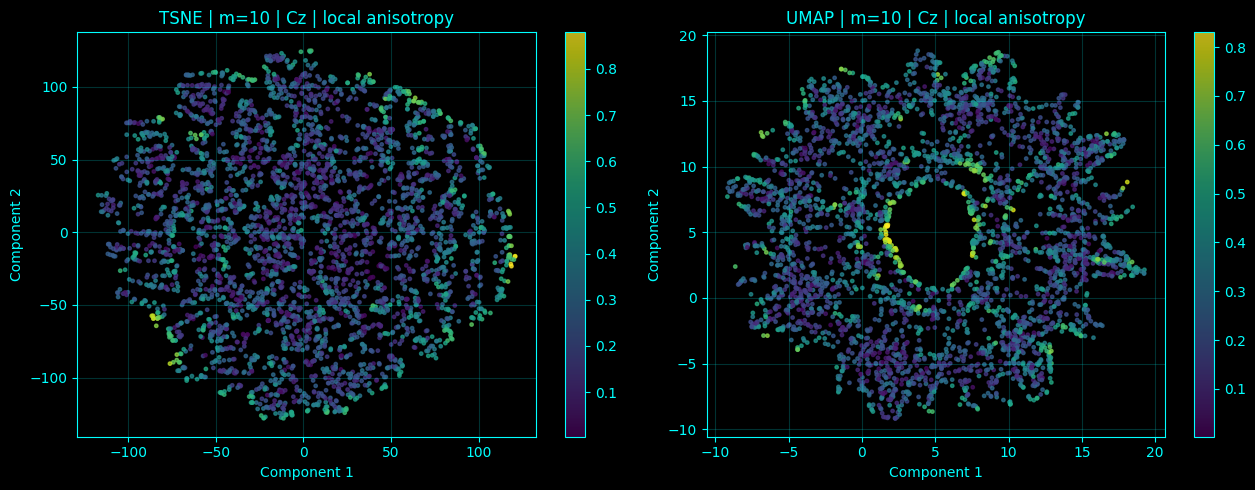

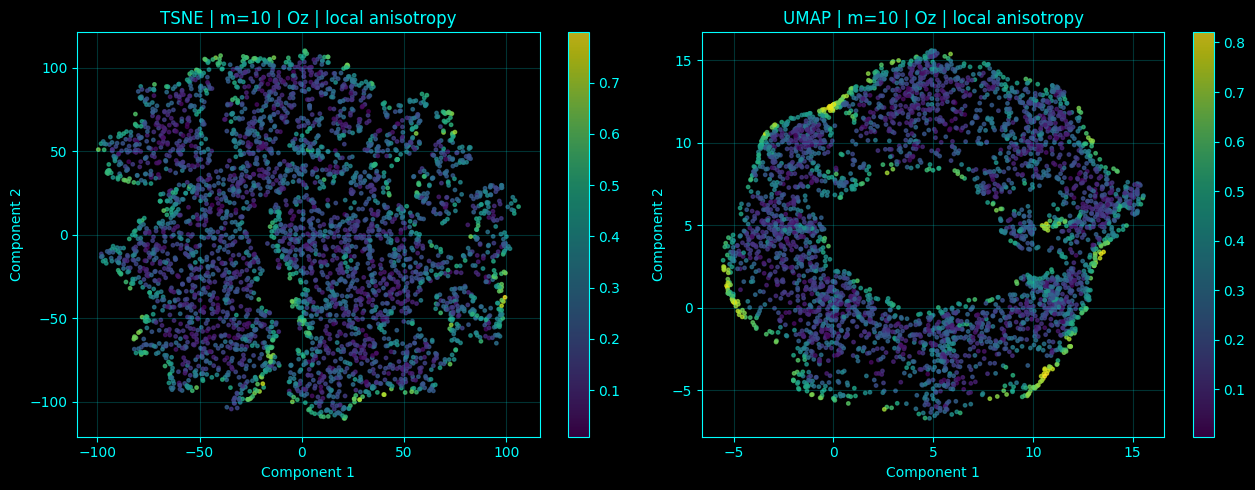


Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/tsne_umap_local_geometry_from_saved_outputs_optimized/tsne_umap_saved_output_geometry_summary.csv
Saved method-dimension CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/tsne_umap_local_geometry_from_saved_outputs_optimized/tsne_umap_method_dim_summary.csv
Saved channel CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/tsne_umap_local_geometry_from_saved_outputs_optimized/tsne_umap_channel_dim_summary.csv
Saved example local geometry CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/tsne_umap_local_geometry_from_saved_outputs_optimized/tsne_umap_example_local_geometry_points.csv
Saved summary TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/tsne_umap_local_geometry_from_saved_outputs_optimized/tsne_umap_local_geometry_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/tsne_umap_local_geometry_from_saved_outputs_optimized/plots


In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

dir_3d = os.path.join(base_dir, "embedding_data", "tsne_umap_from_3d")
dir_4to10 = os.path.join(base_dir, "embedding_data", "tsne_umap_4to10")

out_dir = os.path.join(base_dir, "results", "tsne_umap_local_geometry_from_saved_outputs_optimized")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# Main optimization knobs
max_points_per_file = 4000     # local geometry is computed on a subsample of each saved 2D embedding
k_neighbors = 40
metric_reg = 1e-6
rng_seed = 42

# Save per-point local geometry only for selected example files
save_example_point_geometry = True
example_dims = [3, 10]
example_channels = ["Fp1", "Cz", "Oz"]

ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# FILE HELPERS
# -------------------------------------------------------
def parse_embedding_file(path):
    """
    Returns:
        method: 'tsne' or 'umap'
        source_emb_dim: int
        channel: str
        source_group: 'from_3d' or 'from_4to10'
    """
    fname = os.path.basename(path)
    stem = os.path.splitext(fname)[0]

    m = re.match(r"^(umap|tsne)_embedding_(.+)$", stem)
    if m:
        method = m.group(1)
        channel = m.group(2)
        return method, 3, channel, "from_3d"

    m = re.match(r"^(umap|tsne)_m(\d+)_(.+)$", stem)
    if m:
        method = m.group(1)
        source_emb_dim = int(m.group(2))
        channel = m.group(3)
        return method, source_emb_dim, channel, "from_4to10"

    raise ValueError(f"Unrecognized embedding filename format: {fname}")

def gather_saved_embedding_files():
    files = []
    for d in [dir_3d, dir_4to10]:
        if os.path.isdir(d):
            files.extend(glob.glob(os.path.join(d, "*.npy")))
    return files

def file_sort_key(path):
    method, source_emb_dim, channel, source_group = parse_embedding_file(path)
    method_order = {"tsne": 0, "umap": 1}
    group_order = {"from_3d": 0, "from_4to10": 1}
    return (method_order[method], source_emb_dim, channel, group_order[source_group], os.path.basename(path))

def subsample_rows(X, max_points, rng):
    X = np.asarray(X, dtype=float)
    n = len(X)
    if max_points is None or n <= max_points:
        return X, np.arange(n, dtype=int)

    idx = np.sort(rng.choice(n, size=max_points, replace=False))
    return X[idx], idx

# -------------------------------------------------------
# GEOMETRY HELPERS
# -------------------------------------------------------
def global_metric_tensor(X):
    C = np.cov(X, rowvar=False)
    return 0.5 * (C + C.T)

def principal_angle_deg(C):
    w, V = np.linalg.eigh(C)
    idx = np.argmax(w)
    v = V[:, idx]
    return float(np.degrees(np.arctan2(v[1], v[0])))

def local_metric_field(X, k=40, reg=1e-6):
    """
    Local geometry proxy from neighborhood covariance on a 2D point cloud.
    """
    X = np.asarray(X, dtype=float)
    n = len(X)

    tree = cKDTree(X)
    _, nbr_idx = tree.query(X, k=min(k + 1, n))

    local_trace = np.zeros(n, dtype=float)
    local_det = np.zeros(n, dtype=float)
    local_logdet = np.zeros(n, dtype=float)
    local_anisotropy = np.zeros(n, dtype=float)
    local_eig_small = np.zeros(n, dtype=float)
    local_eig_large = np.zeros(n, dtype=float)
    local_angle_deg = np.zeros(n, dtype=float)
    local_density_radius = np.zeros(n, dtype=float)

    for i in range(n):
        idx = np.atleast_1d(nbr_idx[i])
        idx = idx[idx != i]
        if len(idx) < 3:
            idx = np.atleast_1d(nbr_idx[i])

        Xi = X[idx]
        Xi_centered = Xi - np.mean(Xi, axis=0, keepdims=True)

        C = (Xi_centered.T @ Xi_centered) / max(len(Xi_centered) - 1, 1)
        C = 0.5 * (C + C.T) + reg * np.eye(2)

        w, V = np.linalg.eigh(C)
        w = np.maximum(w, reg)

        local_trace[i] = np.trace(C)
        local_det[i] = np.linalg.det(C)
        local_logdet[i] = np.log(local_det[i] + eps)
        local_eig_small[i] = w[0]
        local_eig_large[i] = w[1]
        local_anisotropy[i] = (w[1] - w[0]) / (w[1] + w[0] + eps)
        local_angle_deg[i] = np.degrees(np.arctan2(V[1, 1], V[0, 1]))

        dists = np.linalg.norm(X[idx] - X[i], axis=1)
        local_density_radius[i] = float(np.mean(dists))

    return pd.DataFrame({
        "x": X[:, 0],
        "y": X[:, 1],
        "local_trace": local_trace,
        "local_det": local_det,
        "local_logdet": local_logdet,
        "local_anisotropy": local_anisotropy,
        "local_eig_small": local_eig_small,
        "local_eig_large": local_eig_large,
        "local_angle_deg": local_angle_deg,
        "local_density_radius": local_density_radius,
    })

def build_embedding_summary(method, source_emb_dim, channel, source_group, source_file, X_full, X_used, local_df):
    C = global_metric_tensor(X_used)
    eig = np.linalg.eigvalsh(C)

    return {
        "method": method,
        "source_emb_dim": source_emb_dim,
        "channel": channel,
        "source_group": source_group,
        "source_file": source_file,
        "n_points_full": int(len(X_full)),
        "n_points_used": int(len(X_used)),
        "sampling_fraction": float(len(X_used) / max(len(X_full), 1)),
        "global_trace": float(np.trace(C)),
        "global_det": float(np.linalg.det(C)),
        "global_eig_small": float(eig[0]),
        "global_eig_large": float(eig[1]),
        "global_anisotropy": float((eig[1] - eig[0]) / (eig[1] + eig[0] + eps)),
        "global_principal_angle_deg": principal_angle_deg(C),
        "mean_local_trace": float(np.mean(local_df["local_trace"])),
        "mean_local_det": float(np.mean(local_df["local_det"])),
        "mean_local_logdet": float(np.mean(local_df["local_logdet"])),
        "std_local_logdet": float(np.std(local_df["local_logdet"])),
        "mean_local_anisotropy": float(np.mean(local_df["local_anisotropy"])),
        "std_local_anisotropy": float(np.std(local_df["local_anisotropy"])),
        "mean_local_density_radius": float(np.mean(local_df["local_density_radius"])),
        "std_local_density_radius": float(np.std(local_df["local_density_radius"])),
    }

# -------------------------------------------------------
# MAIN
# -------------------------------------------------------
rng = np.random.default_rng(rng_seed)

file_paths = gather_saved_embedding_files()
if len(file_paths) == 0:
    raise FileNotFoundError("No saved t-SNE / UMAP .npy files found.")

file_paths = sorted(file_paths, key=file_sort_key)

print(f"Found {len(file_paths)} saved t-SNE / UMAP files")
print(f"Using max_points_per_file={max_points_per_file}, k_neighbors={k_neighbors}")

summary_rows = []
example_local_rows = []

for file_idx, fp in enumerate(file_paths, start=1):
    method, source_emb_dim, channel, source_group = parse_embedding_file(fp)

    X = np.load(fp, allow_pickle=True)
    X = np.asarray(X, dtype=float)

    if X.ndim != 2 or X.shape[1] != 2:
        print(f"Skipping {fp}: expected shape (N,2), got {X.shape}")
        continue

    X_used, used_idx = subsample_rows(X, max_points=max_points_per_file, rng=rng)

    print(
        f"[{file_idx}/{len(file_paths)}] "
        f"{os.path.basename(fp)} | method={method} | source_dim={source_emb_dim} | "
        f"channel={channel} | full={len(X)} | used={len(X_used)}"
    )

    local_df = local_metric_field(X_used, k=k_neighbors, reg=metric_reg)

    summary_rows.append(
        build_embedding_summary(
            method=method,
            source_emb_dim=source_emb_dim,
            channel=channel,
            source_group=source_group,
            source_file=os.path.basename(fp),
            X_full=X,
            X_used=X_used,
            local_df=local_df,
        )
    )

    if save_example_point_geometry and (source_emb_dim in example_dims) and (channel in example_channels):
        local_df = local_df.copy()
        local_df["method"] = method
        local_df["source_emb_dim"] = source_emb_dim
        local_df["channel"] = channel
        local_df["source_group"] = source_group
        local_df["source_file"] = os.path.basename(fp)
        local_df["original_index"] = used_idx
        example_local_rows.append(local_df)

summary_df = pd.DataFrame(summary_rows)

# -------------------------------------------------------
# AGGREGATED SUMMARIES
# -------------------------------------------------------
method_dim_summary_df = (
    summary_df.groupby(["method", "source_emb_dim"], as_index=False)
    .agg(
        n_embeddings=("channel", "count"),
        mean_points_full=("n_points_full", "mean"),
        mean_points_used=("n_points_used", "mean"),
        mean_sampling_fraction=("sampling_fraction", "mean"),
        mean_global_anisotropy=("global_anisotropy", "mean"),
        std_global_anisotropy=("global_anisotropy", "std"),
        mean_local_anisotropy=("mean_local_anisotropy", "mean"),
        std_local_anisotropy=("mean_local_anisotropy", "std"),
        mean_local_logdet=("mean_local_logdet", "mean"),
        std_local_logdet=("mean_local_logdet", "std"),
        mean_local_density_radius=("mean_local_density_radius", "mean"),
        std_local_density_radius=("mean_local_density_radius", "std"),
    )
    .sort_values(["method", "source_emb_dim"])
)

channel_summary_df = (
    summary_df.groupby(["method", "source_emb_dim", "channel"], as_index=False)
    .agg(
        n_points_full=("n_points_full", "mean"),
        n_points_used=("n_points_used", "mean"),
        global_anisotropy=("global_anisotropy", "mean"),
        mean_local_anisotropy=("mean_local_anisotropy", "mean"),
        mean_local_logdet=("mean_local_logdet", "mean"),
        mean_local_density_radius=("mean_local_density_radius", "mean"),
    )
    .sort_values(["method", "source_emb_dim", "channel"])
)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
summary_csv = os.path.join(out_dir, "tsne_umap_saved_output_geometry_summary.csv")
method_dim_csv = os.path.join(out_dir, "tsne_umap_method_dim_summary.csv")
channel_csv = os.path.join(out_dir, "tsne_umap_channel_dim_summary.csv")
summary_txt = os.path.join(out_dir, "tsne_umap_local_geometry_summary.txt")

summary_df.to_csv(summary_csv, index=False)
method_dim_summary_df.to_csv(method_dim_csv, index=False)
channel_summary_df.to_csv(channel_csv, index=False)

example_local_csv = None
if len(example_local_rows) > 0:
    example_local_df = pd.concat(example_local_rows, axis=0, ignore_index=True)
    example_local_csv = os.path.join(out_dir, "tsne_umap_example_local_geometry_points.csv")
    example_local_df.to_csv(example_local_csv, index=False)

with open(summary_txt, "w") as f:
    f.write("Optimized Local Geometry of Saved t-SNE / UMAP Outputs\n")
    f.write("=====================================================\n\n")
    f.write("This version computes full per-file summaries for all saved t-SNE / UMAP outputs,\n")
    f.write("but only on a per-file subsample to keep runtime and memory manageable.\n")
    f.write("Per-point local geometry is saved only for selected example files.\n\n")
    f.write(f"Files analyzed: {len(summary_df)}\n")
    f.write(f"max_points_per_file: {max_points_per_file}\n")
    f.write(f"k-neighbors: {k_neighbors}\n")
    f.write(f"metric regularization: {metric_reg}\n\n")

    for _, row in method_dim_summary_df.iterrows():
        f.write(
            f"{row['method']} | source_dim={int(row['source_emb_dim'])}: "
            f"n_embeddings={int(row['n_embeddings'])}, "
            f"mean_points_used={row['mean_points_used']:.1f}, "
            f"mean_global_anisotropy={row['mean_global_anisotropy']:.6f}, "
            f"mean_local_anisotropy={row['mean_local_anisotropy']:.6f}, "
            f"mean_local_logdet={row['mean_local_logdet']:.6f}, "
            f"mean_local_density_radius={row['mean_local_density_radius']:.6f}\n"
        )

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------
# 1) Mean local anisotropy vs source embedding dimension
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

for method in sorted(method_dim_summary_df["method"].unique()):
    sub = method_dim_summary_df[method_dim_summary_df["method"] == method].sort_values("source_emb_dim")
    ax.plot(
        sub["source_emb_dim"].values,
        sub["mean_local_anisotropy"].values,
        marker="o",
        linewidth=1.5,
        label=method
    )

ax.set_title("Mean Local Anisotropy vs Source Embedding Dimension")
ax.set_xlabel("Source Embedding Dimension")
ax.set_ylabel("Mean Local Anisotropy")
ax.legend()

plot1_path = os.path.join(plots_dir, "mean_local_anisotropy_vs_source_dim.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Mean local logdet vs source embedding dimension
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

for method in sorted(method_dim_summary_df["method"].unique()):
    sub = method_dim_summary_df[method_dim_summary_df["method"] == method].sort_values("source_emb_dim")
    ax.plot(
        sub["source_emb_dim"].values,
        sub["mean_local_logdet"].values,
        marker="o",
        linewidth=1.5,
        label=method
    )

ax.set_title("Mean Local log det(g) vs Source Embedding Dimension")
ax.set_xlabel("Source Embedding Dimension")
ax.set_ylabel("Mean Local log det(g)")
ax.legend()

plot2_path = os.path.join(plots_dir, "mean_local_logdet_vs_source_dim.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Mean local density radius vs source embedding dimension
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

for method in sorted(method_dim_summary_df["method"].unique()):
    sub = method_dim_summary_df[method_dim_summary_df["method"] == method].sort_values("source_emb_dim")
    ax.plot(
        sub["source_emb_dim"].values,
        sub["mean_local_density_radius"].values,
        marker="o",
        linewidth=1.5,
        label=method
    )

ax.set_title("Mean Local Density Radius vs Source Embedding Dimension")
ax.set_xlabel("Source Embedding Dimension")
ax.set_ylabel("Mean Local Density Radius")
ax.legend()

plot3_path = os.path.join(plots_dir, "mean_local_density_radius_vs_source_dim.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Mean sample size used vs source dimension
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

for method in sorted(method_dim_summary_df["method"].unique()):
    sub = method_dim_summary_df[method_dim_summary_df["method"] == method].sort_values("source_emb_dim")
    ax.plot(
        sub["source_emb_dim"].values,
        sub["mean_points_used"].values,
        marker="o",
        linewidth=1.5,
        label=method
    )

ax.set_title("Mean Sample Size Used per File vs Source Dimension")
ax.set_xlabel("Source Embedding Dimension")
ax.set_ylabel("Mean Points Used")
ax.legend()

plot4_path = os.path.join(plots_dir, "mean_points_used_vs_source_dim.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Example local anisotropy maps for selected example files
if len(example_local_rows) > 0:
    example_local_df = pd.concat(example_local_rows, axis=0, ignore_index=True)

    for d in example_dims:
        for ch in example_channels:
            sub = example_local_df[
                (example_local_df["source_emb_dim"] == d) &
                (example_local_df["channel"] == ch)
            ]

            if len(sub) == 0:
                continue

            fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)
            for ax in axes:
                style_ax(ax)

            for ax, method in zip(axes, ["tsne", "umap"]):
                ss = sub[sub["method"] == method]
                if len(ss) == 0:
                    ax.set_title(f"{method.upper()} | m={d} | {ch} | no data")
                    continue

                sc = ax.scatter(
                    ss["x"], ss["y"],
                    c=ss["local_anisotropy"],
                    s=6,
                    alpha=0.75
                )
                ax.set_title(f"{method.upper()} | m={d} | {ch} | local anisotropy")
                ax.set_xlabel("Component 1")
                ax.set_ylabel("Component 2")

                cbar = plt.colorbar(sc, ax=ax)
                cbar.outline.set_edgecolor(ACCENT)
                cbar.ax.tick_params(color=ACCENT)
                for label in cbar.ax.get_yticklabels():
                    label.set_color(ACCENT)

            out_path = os.path.join(plots_dir, f"example_local_anisotropy_m{d}_{ch}.png")
            plt.tight_layout()
            plt.savefig(out_path, dpi=180, bbox_inches="tight")
            plt.show()
            plt.close()

print(f"\nSaved summary CSV: {summary_csv}")
print(f"Saved method-dimension CSV: {method_dim_csv}")
print(f"Saved channel CSV: {channel_csv}")
if example_local_csv is not None:
    print(f"Saved example local geometry CSV: {example_local_csv}")
print(f"Saved summary TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

### Local Hermitian Metric Field on the Analytic EEG State Cloud

Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
Sampled states for local geometry: 12000


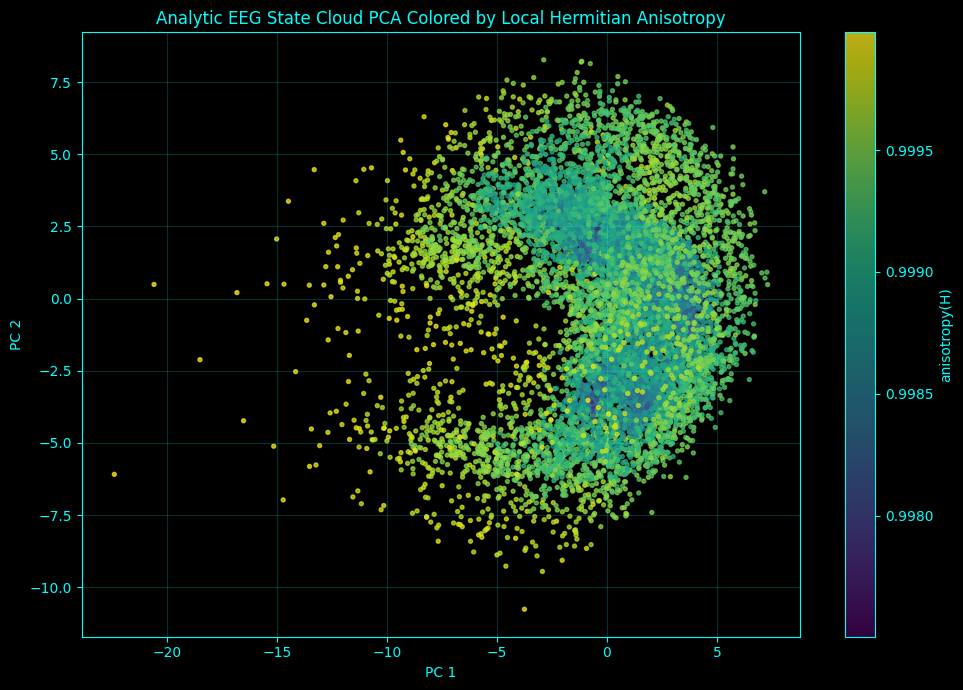

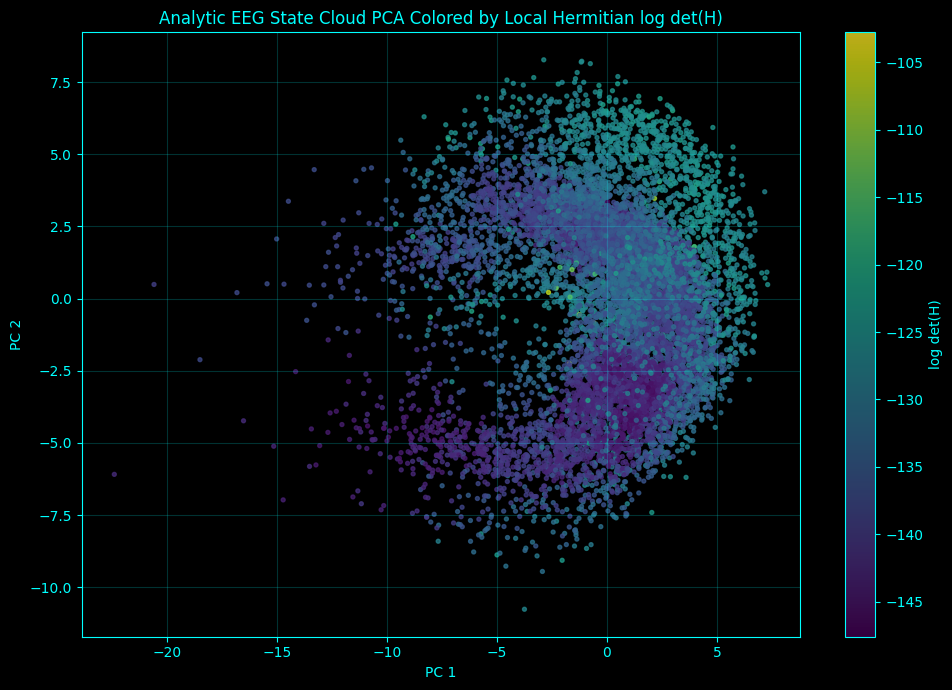

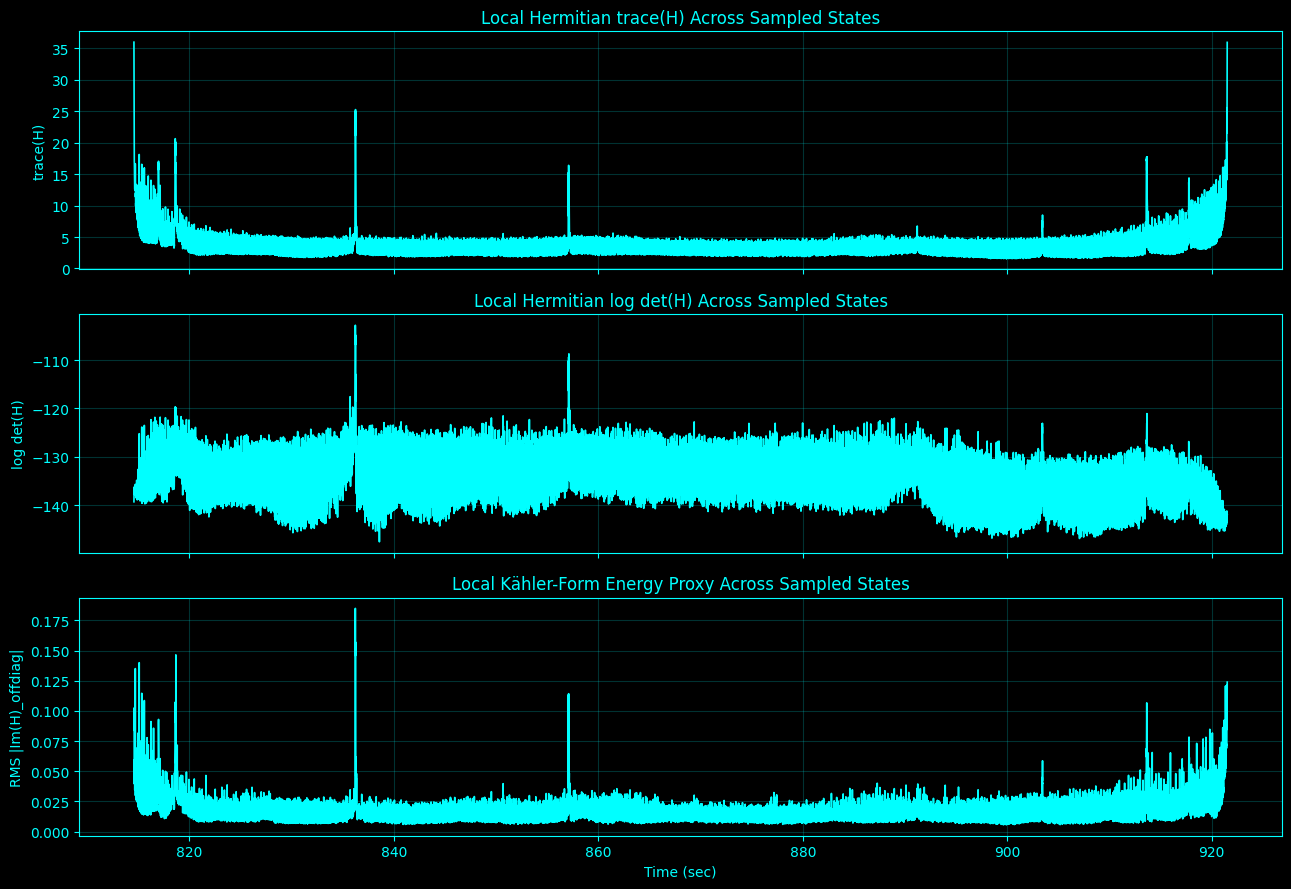

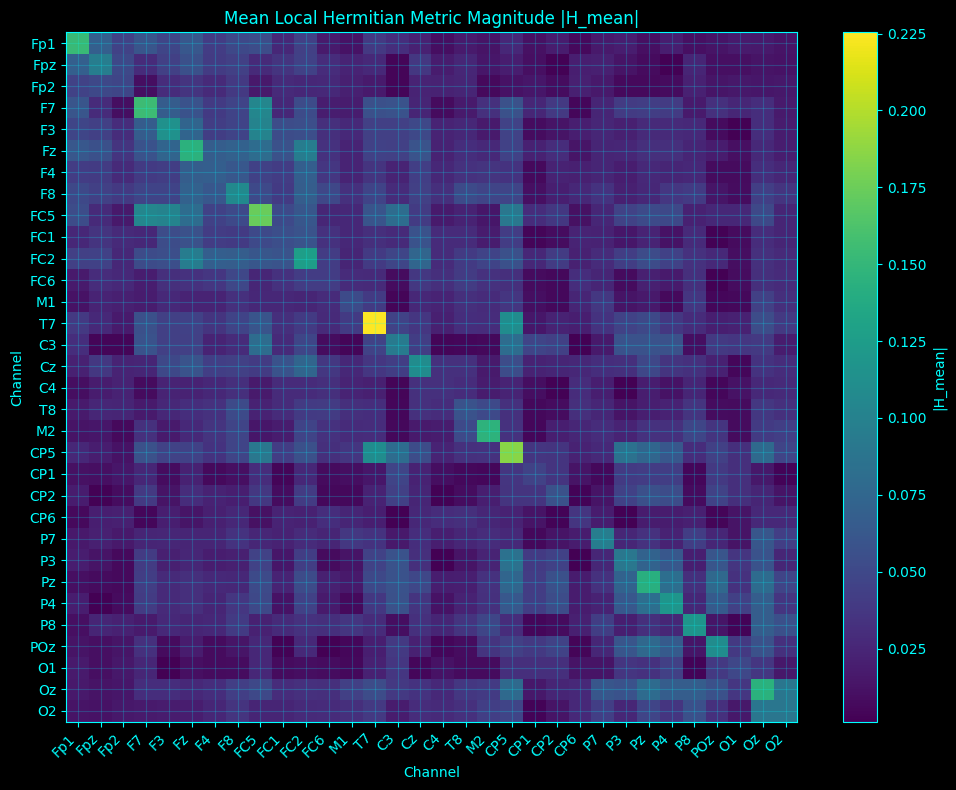

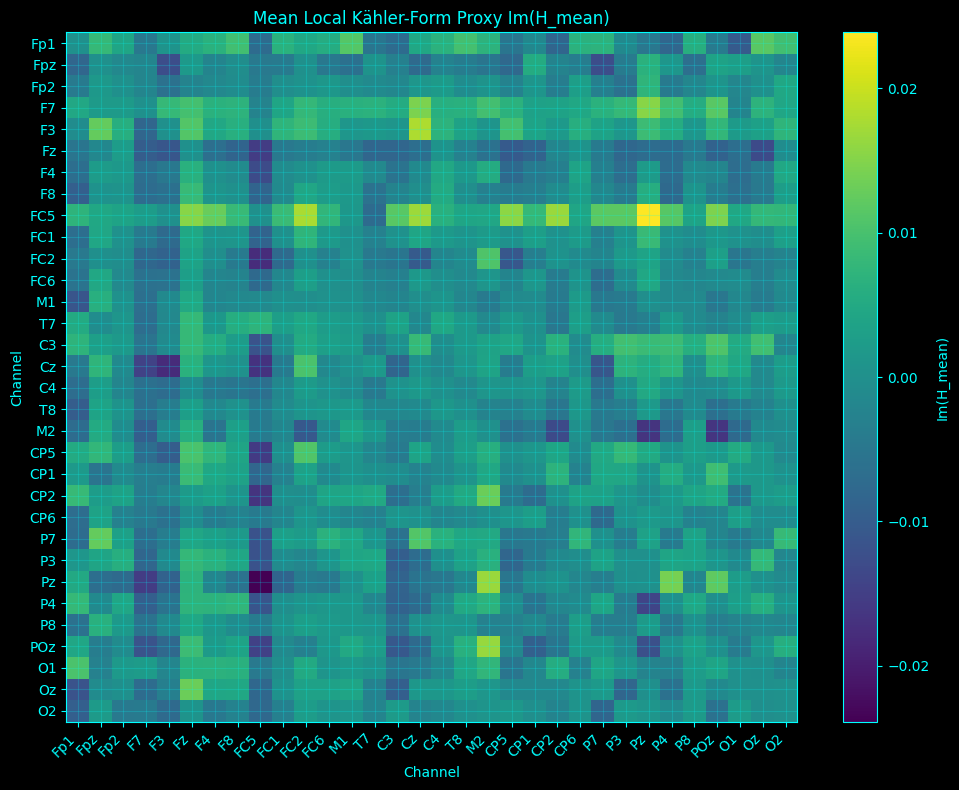

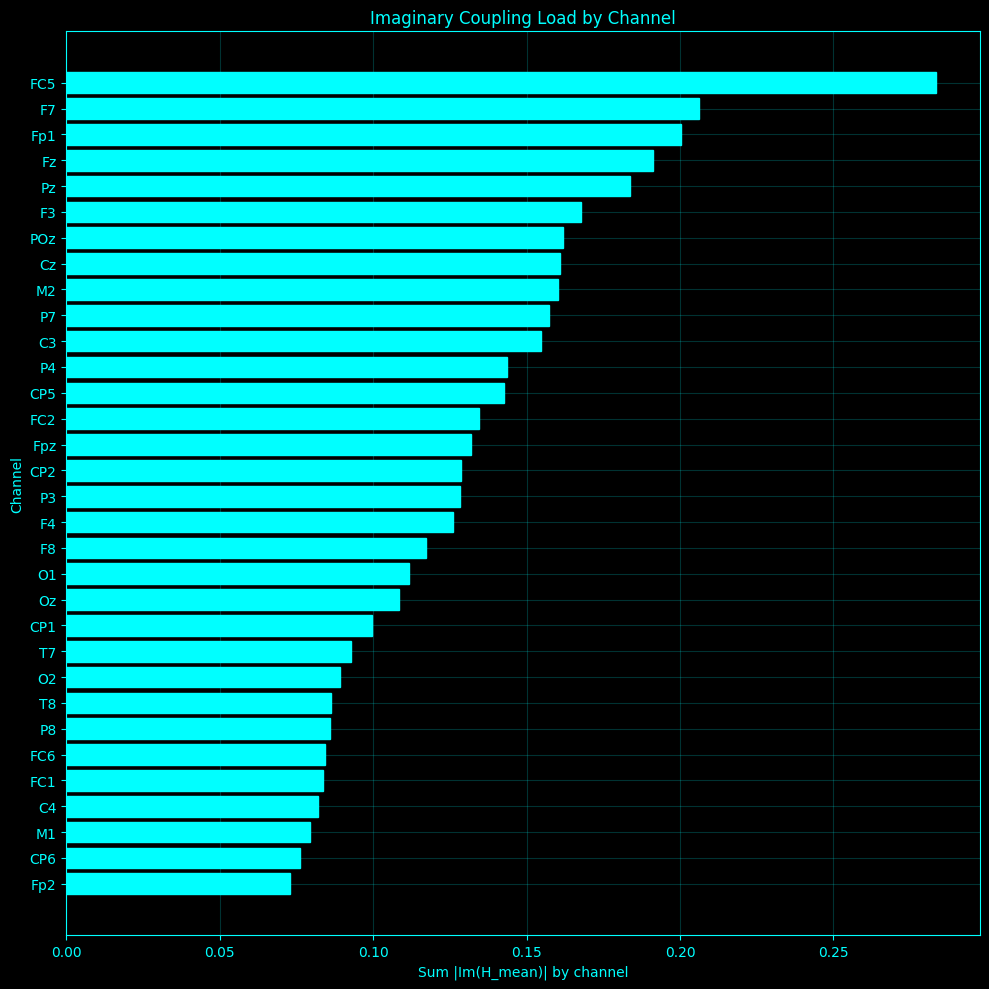


Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/local_hermitian_metric_field/local_hermitian_metric_field_summary.csv
Saved diagonal energy CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/local_hermitian_metric_field/local_hermitian_diagonal_channel_energy.csv
Saved imaginary load CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/local_hermitian_metric_field/local_hermitian_imaginary_channel_load.csv
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/local_hermitian_metric_field/local_hermitian_metric_field_results.npz
Saved summary TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/local_hermitian_metric_field/local_hermitian_metric_field_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/local_hermitian_metric_field/plots


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.spatial import cKDTree

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "local_hermitian_metric_field")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
dt = 1.0 / sampling_rate

start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# Geometry controls
max_state_points = 12000       # subsample state cloud for tractable local geometry
k_neighbors = 80               # local neighborhood size
metric_reg = 1e-6              # diagonal regularization
save_metric_tensors_for = 250  # save full H only for first N sampled states

rng_seed = 42

ACCENT = "cyan"
BG = "black"
eps = 1e-12

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)

    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")

    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T

    raise ValueError(f"Unexpected EEG shape: {x.shape}")

def complex_zscore_by_channel(z):
    z = np.asarray(z, dtype=np.complex128)
    mu = np.mean(z, axis=0, keepdims=True)
    zc = z - mu
    rms = np.sqrt(np.mean(np.abs(zc) ** 2, axis=0, keepdims=True))
    return zc / (rms + eps)

def realify_complex_states(Z):
    """
    C^n -> R^(2n) for neighbor search.
    """
    return np.concatenate([np.real(Z), np.imag(Z)], axis=1)

def uniform_subsample_indices(n, max_n):
    if max_n is None or n <= max_n:
        return np.arange(n, dtype=int)
    return np.linspace(0, n - 1, max_n).astype(int)

def hermitian_covariance(Z_local, reg=1e-6):
    """
    Local Hermitian metric proxy:
        H = X^* X / (L-1)
    """
    X = Z_local - np.mean(Z_local, axis=0, keepdims=True)
    L = X.shape[0]
    H = (X.conj().T @ X) / max(L - 1, 1)
    H = 0.5 * (H + H.conj().T)
    H = H + reg * np.eye(H.shape[0], dtype=np.complex128)
    return H

def hermitian_to_parts(H):
    G = np.real(H)
    W = np.imag(H)
    G = 0.5 * (G + G.T)
    W = 0.5 * (W - W.T)
    return G, W

def coherence_from_hermitian(H):
    d = np.real(np.diag(H))
    denom = np.sqrt(np.outer(d, d)) + eps
    C = H / denom
    np.fill_diagonal(C, 1.0 + 0j)
    return C

def offdiag_mean_abs(M):
    mask = ~np.eye(M.shape[0], dtype=bool)
    return float(np.mean(np.abs(M[mask])))

def offdiag_rms_abs(M):
    mask = ~np.eye(M.shape[0], dtype=bool)
    return float(np.sqrt(np.mean(np.abs(M[mask]) ** 2)))

def normalized_eig_entropy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[vals > 0]
    if len(vals) == 0:
        return np.nan
    p = vals / (np.sum(vals) + eps)
    H = -np.sum(p * np.log(p + eps))
    Hmax = np.log(len(p) + eps)
    return float(H / (Hmax + eps))

def participation_ratio(vals):
    vals = np.asarray(vals, dtype=float)
    return float((np.sum(vals) ** 2) / (np.sum(vals ** 2) + eps))

def pca_2d(X):
    """
    Simple PCA to 2D using eigendecomposition.
    """
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(len(Xc) - 1, 1)
    w, V = np.linalg.eigh(C)
    idx = np.argsort(w)[::-1][:2]
    Y = Xc @ V[:, idx]
    return Y, w[idx], V[:, idx]

# -------------------------------------------------------
# LOAD EEG
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channel_names))
EEG_segment = EEG_data[start_index:end_index, :]

n_samples, n_channels = EEG_segment.shape
time_sec = start_time + np.arange(n_samples) * dt

print(f"Loaded EEG segment: {n_samples} samples x {n_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

# -------------------------------------------------------
# ANALYTIC EEG STATE CLOUD
# -------------------------------------------------------
analytic_EEG = hilbert(EEG_segment, axis=0)
analytic_EEG = complex_zscore_by_channel(analytic_EEG)

sample_idx = uniform_subsample_indices(n_samples, max_state_points)
Z_sample = analytic_EEG[sample_idx, :]                  # (N_sub, 32) complex
T_sample = time_sec[sample_idx]
X_real = realify_complex_states(Z_sample)               # (N_sub, 64) real

print(f"Sampled states for local geometry: {len(sample_idx)}")

# -------------------------------------------------------
# NEIGHBOR SEARCH
# -------------------------------------------------------
tree = cKDTree(X_real)
_, nbr_idx = tree.query(X_real, k=min(k_neighbors + 1, len(X_real)))

# -------------------------------------------------------
# LOCAL HERMITIAN METRIC FIELD
# -------------------------------------------------------
summary_rows = []
H_subset = []
H_mean = np.zeros((n_channels, n_channels), dtype=np.complex128)

for i in range(len(X_real)):
    idx = np.atleast_1d(nbr_idx[i])
    idx = idx[idx != i]
    if len(idx) < 3:
        idx = np.atleast_1d(nbr_idx[i])

    Z_local = Z_sample[idx, :]
    H = hermitian_covariance(Z_local, reg=metric_reg)
    G, W = hermitian_to_parts(H)
    C = coherence_from_hermitian(H)

    eigvals = np.linalg.eigvalsh(H)
    eigvals = np.maximum(np.real(eigvals), metric_reg)

    trace_H = float(np.real(np.trace(H)))
    logdet_H = float(np.sum(np.log(eigvals + eps)))
    anisotropy_H = float((eigvals[-1] - eigvals[0]) / (eigvals[-1] + eigvals[0] + eps))
    eig_entropy = normalized_eig_entropy(eigvals)
    pr = participation_ratio(eigvals)

    mean_abs_real_offdiag = offdiag_mean_abs(G)
    mean_abs_imag_offdiag = offdiag_mean_abs(W)
    mean_abs_coherence_offdiag = offdiag_mean_abs(C)
    kahler_energy_proxy = offdiag_rms_abs(W)

    mean_neighbor_radius = float(np.mean(np.linalg.norm(X_real[idx] - X_real[i], axis=1)))

    summary_rows.append({
        "state_index_original": int(sample_idx[i]),
        "state_index_subsampled": int(i),
        "time_sec": float(T_sample[i]),
        "trace_H": trace_H,
        "logdet_H": logdet_H,
        "anisotropy_H": anisotropy_H,
        "eig_entropy_H": eig_entropy,
        "participation_ratio_H": pr,
        "mean_abs_real_offdiag": mean_abs_real_offdiag,
        "mean_abs_imag_offdiag": mean_abs_imag_offdiag,
        "mean_abs_coherence_offdiag": mean_abs_coherence_offdiag,
        "kahler_energy_proxy": kahler_energy_proxy,
        "mean_neighbor_radius": mean_neighbor_radius,
    })

    H_mean += H

    if i < save_metric_tensors_for:
        H_subset.append(H)

H_mean /= len(X_real)
G_mean, W_mean = hermitian_to_parts(H_mean)
C_mean = coherence_from_hermitian(H_mean)

summary_df = pd.DataFrame(summary_rows)

# -------------------------------------------------------
# CHANNEL-LEVEL SUMMARIES
# -------------------------------------------------------
diag_energy_df = pd.DataFrame({
    "channel": eeg_channel_names,
    "diag_real_metric": np.real(np.diag(G_mean)),
    "diag_complex_power": np.real(np.diag(H_mean)),
})

imag_load = np.sum(np.abs(W_mean), axis=1)
imag_load_df = pd.DataFrame({
    "channel": eeg_channel_names,
    "imaginary_coupling_load": imag_load,
}).sort_values("imaginary_coupling_load", ascending=False).reset_index(drop=True)

# -------------------------------------------------------
# PCA FOR VISUALIZATION
# -------------------------------------------------------
pca_xy, pca_eigs, _ = pca_2d(X_real)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
summary_csv = os.path.join(out_dir, "local_hermitian_metric_field_summary.csv")
diag_csv = os.path.join(out_dir, "local_hermitian_diagonal_channel_energy.csv")
imag_csv = os.path.join(out_dir, "local_hermitian_imaginary_channel_load.csv")
npz_path = os.path.join(out_dir, "local_hermitian_metric_field_results.npz")
summary_txt = os.path.join(out_dir, "local_hermitian_metric_field_summary.txt")

summary_df.to_csv(summary_csv, index=False)
diag_energy_df.to_csv(diag_csv, index=False)
imag_load_df.to_csv(imag_csv, index=False)

np.savez_compressed(
    npz_path,
    sample_idx=sample_idx,
    T_sample=T_sample,
    pca_xy=pca_xy,
    H_mean=H_mean,
    G_mean=G_mean,
    W_mean=W_mean,
    C_mean=C_mean,
    H_subset=np.array(H_subset),
    eeg_channel_names=np.array(eeg_channel_names, dtype=object),
    sampling_rate=sampling_rate,
    start_time=start_time,
    end_time=end_time,
    max_state_points=max_state_points,
    k_neighbors=k_neighbors,
    metric_reg=metric_reg,
)

with open(summary_txt, "w") as f:
    f.write("Local Hermitian Metric Field on the Analytic EEG State Cloud\n")
    f.write("===========================================================\n\n")
    f.write("Theory:\n")
    f.write("Each time point of the analytic EEG is treated as a state in C^n.\n")
    f.write("For each sampled state z_i, a local neighborhood is found in the realified state cloud,\n")
    f.write("and a local Hermitian metric proxy is estimated by H_i = X^*X/(L-1).\n")
    f.write("This is the first step toward a state-dependent complex metric field g(z, zbar).\n\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Channels: {n_channels}\n")
    f.write(f"Sampled states: {len(sample_idx)}\n")
    f.write(f"k-neighbors: {k_neighbors}\n")
    f.write(f"metric regularization: {metric_reg}\n\n")
    f.write("Mean field summaries across sampled states:\n")
    f.write(f"  mean trace(H): {summary_df['trace_H'].mean():.6f}\n")
    f.write(f"  mean logdet(H): {summary_df['logdet_H'].mean():.6f}\n")
    f.write(f"  mean anisotropy(H): {summary_df['anisotropy_H'].mean():.6f}\n")
    f.write(f"  mean eig-entropy(H): {summary_df['eig_entropy_H'].mean():.6f}\n")
    f.write(f"  mean participation ratio(H): {summary_df['participation_ratio_H'].mean():.6f}\n")
    f.write(f"  mean |Re(H)_offdiag|: {summary_df['mean_abs_real_offdiag'].mean():.6f}\n")
    f.write(f"  mean |Im(H)_offdiag|: {summary_df['mean_abs_imag_offdiag'].mean():.6f}\n")
    f.write(f"  mean coherence offdiag: {summary_df['mean_abs_coherence_offdiag'].mean():.6f}\n")
    f.write(f"  mean Kähler-energy proxy: {summary_df['kahler_energy_proxy'].mean():.6f}\n")
    f.write(f"  mean neighbor radius: {summary_df['mean_neighbor_radius'].mean():.6f}\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------
# 1) PCA state cloud colored by anisotropy
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    pca_xy[:, 0], pca_xy[:, 1],
    c=summary_df["anisotropy_H"].values,
    s=8, alpha=0.75
)
ax.set_title("Analytic EEG State Cloud PCA Colored by Local Hermitian Anisotropy")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("anisotropy(H)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot1_path = os.path.join(plots_dir, "state_cloud_pca_local_anisotropy.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) PCA state cloud colored by logdet
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    pca_xy[:, 0], pca_xy[:, 1],
    c=summary_df["logdet_H"].values,
    s=8, alpha=0.75
)
ax.set_title("Analytic EEG State Cloud PCA Colored by Local Hermitian log det(H)")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("log det(H)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot2_path = os.path.join(plots_dir, "state_cloud_pca_local_logdet.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Local Hermitian summaries over time
fig, axes = plt.subplots(3, 1, figsize=(13, 9), facecolor=BG, sharex=True)
for ax in axes:
    style_ax(ax)

t = summary_df["time_sec"].values

axes[0].plot(t, summary_df["trace_H"].values, color=ACCENT, linewidth=1.2)
axes[0].set_title("Local Hermitian trace(H) Across Sampled States")
axes[0].set_ylabel("trace(H)")

axes[1].plot(t, summary_df["logdet_H"].values, color=ACCENT, linewidth=1.2)
axes[1].set_title("Local Hermitian log det(H) Across Sampled States")
axes[1].set_ylabel("log det(H)")

axes[2].plot(t, summary_df["kahler_energy_proxy"].values, color=ACCENT, linewidth=1.2)
axes[2].set_title("Local Kähler-Form Energy Proxy Across Sampled States")
axes[2].set_xlabel("Time (sec)")
axes[2].set_ylabel("RMS |Im(H)_offdiag|")

plot3_path = os.path.join(plots_dir, "local_hermitian_time_series.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Mean |H| heatmap
fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
style_ax(ax)

im = ax.imshow(np.abs(H_mean), aspect="auto")
ax.set_title("Mean Local Hermitian Metric Magnitude |H_mean|")
ax.set_xlabel("Channel")
ax.set_ylabel("Channel")
ax.set_xticks(np.arange(n_channels))
ax.set_yticks(np.arange(n_channels))
ax.set_xticklabels(eeg_channel_names, rotation=45, ha="right")
ax.set_yticklabels(eeg_channel_names)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("|H_mean|", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot4_path = os.path.join(plots_dir, "mean_local_hermitian_metric_magnitude.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Mean Kähler-form proxy heatmap
fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
style_ax(ax)

im = ax.imshow(W_mean, aspect="auto")
ax.set_title("Mean Local Kähler-Form Proxy Im(H_mean)")
ax.set_xlabel("Channel")
ax.set_ylabel("Channel")
ax.set_xticks(np.arange(n_channels))
ax.set_yticks(np.arange(n_channels))
ax.set_xticklabels(eeg_channel_names, rotation=45, ha="right")
ax.set_yticklabels(eeg_channel_names)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Im(H_mean)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot5_path = os.path.join(plots_dir, "mean_local_kahler_form_proxy.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 6) Imaginary coupling load by channel
plot_df = imag_load_df.sort_values("imaginary_coupling_load", ascending=True)

fig, ax = plt.subplots(figsize=(10, 10), facecolor=BG)
style_ax(ax)

ax.barh(
    plot_df["channel"].values,
    plot_df["imaginary_coupling_load"].values,
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Imaginary Coupling Load by Channel")
ax.set_xlabel("Sum |Im(H_mean)| by channel")
ax.set_ylabel("Channel")

plot6_path = os.path.join(plots_dir, "imaginary_coupling_load_by_channel.png")
plt.tight_layout()
plt.savefig(plot6_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved summary CSV: {summary_csv}")
print(f"Saved diagonal energy CSV: {diag_csv}")
print(f"Saved imaginary load CSV: {imag_csv}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved summary TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

### Empirical Ricci-form Proxy on the Local Hermitian EEG Manifold

Loaded local Hermitian field summary with 12000 sampled states
PCA chart shape: (12000, 2)


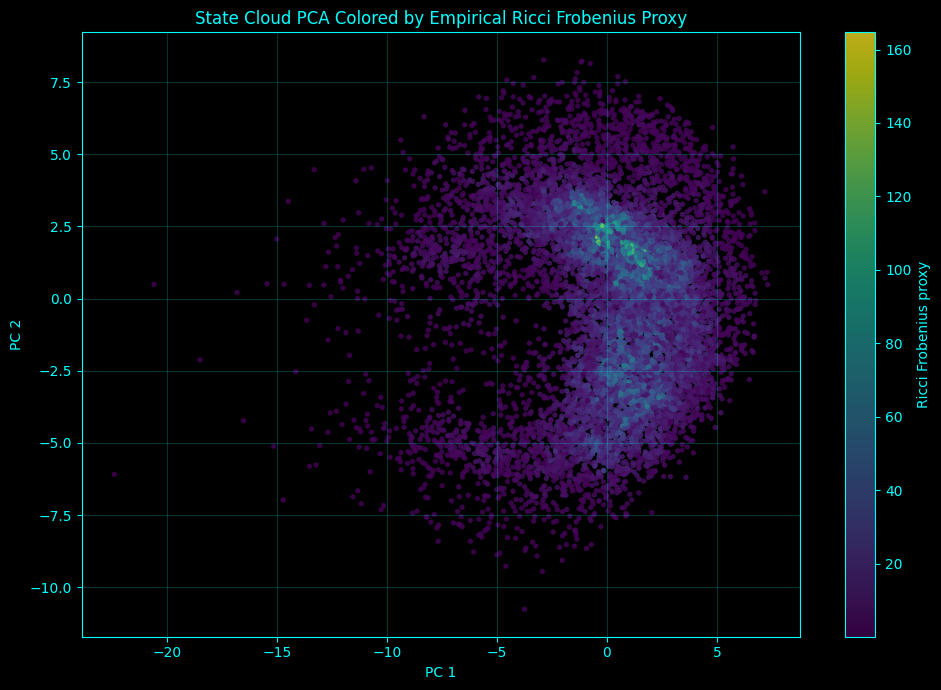

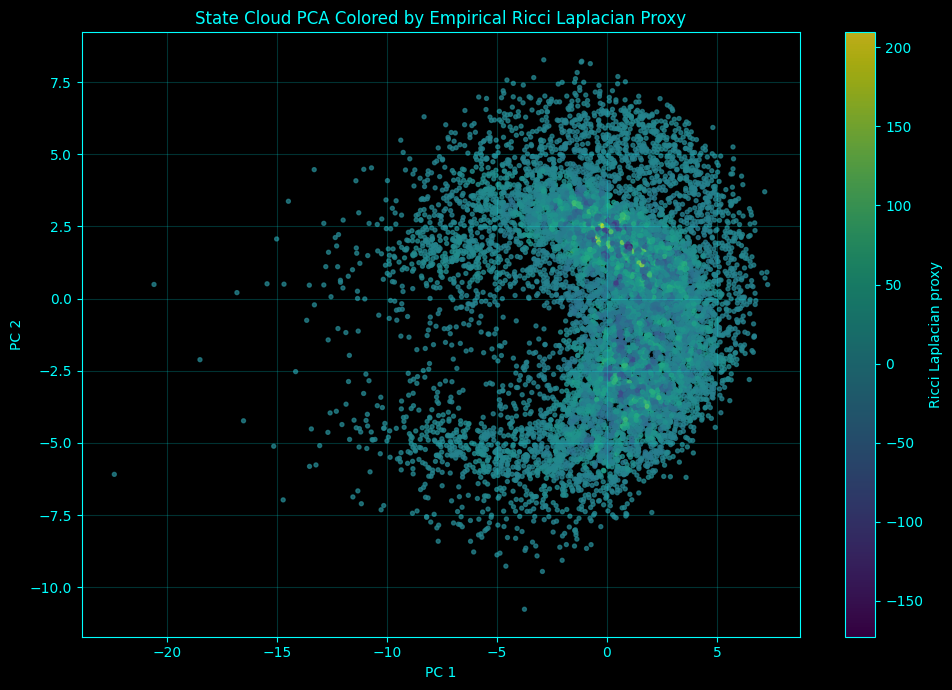

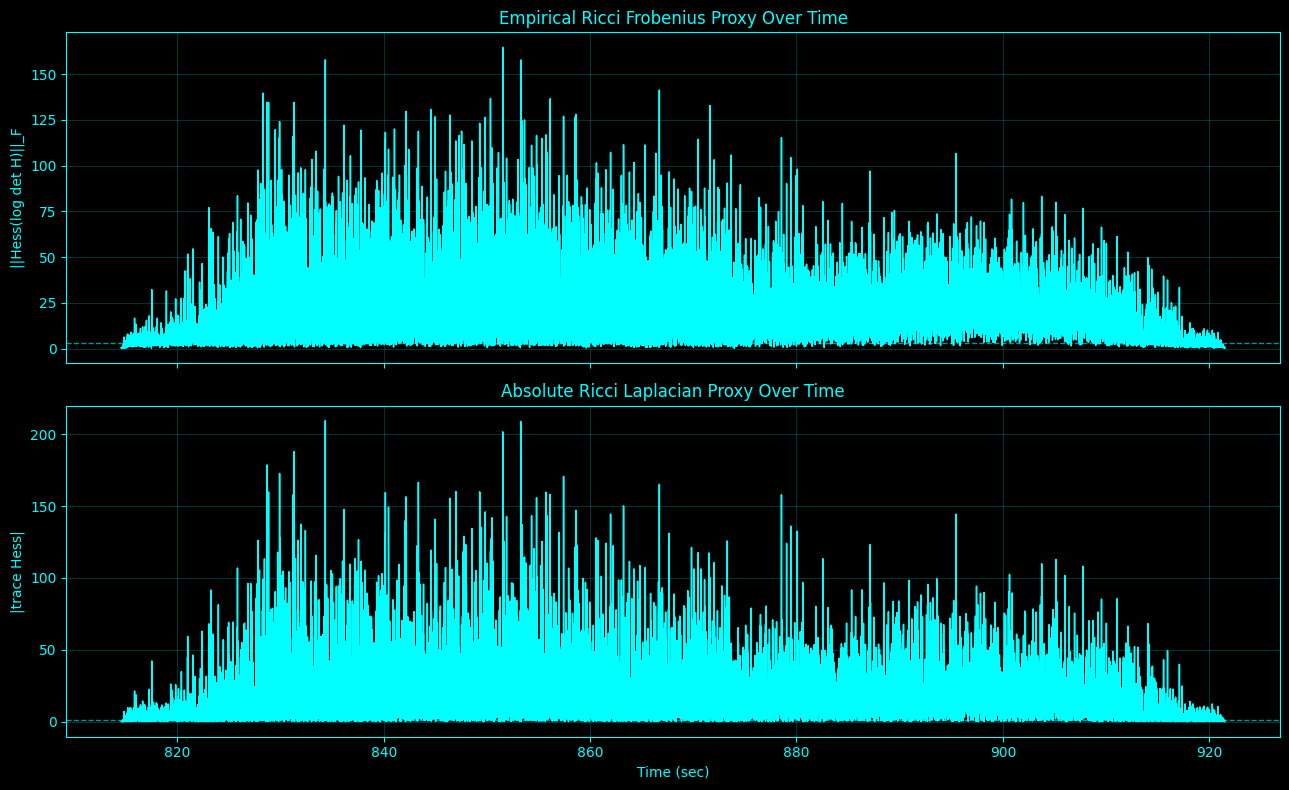

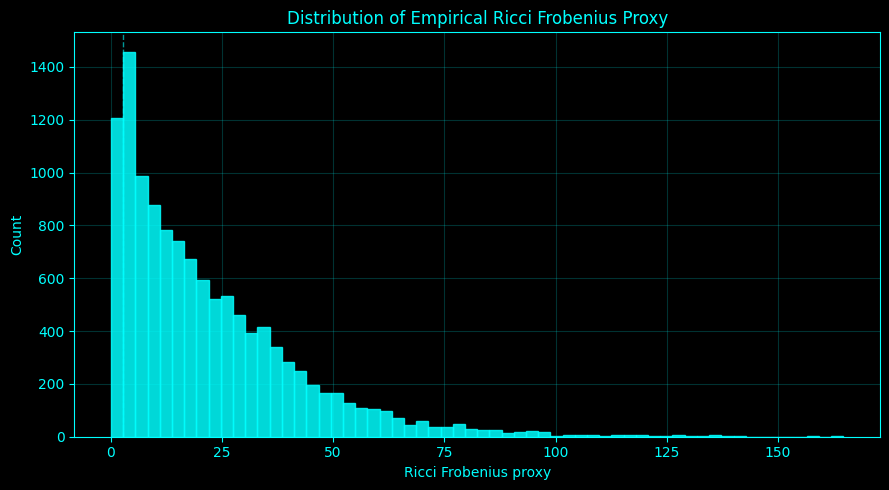

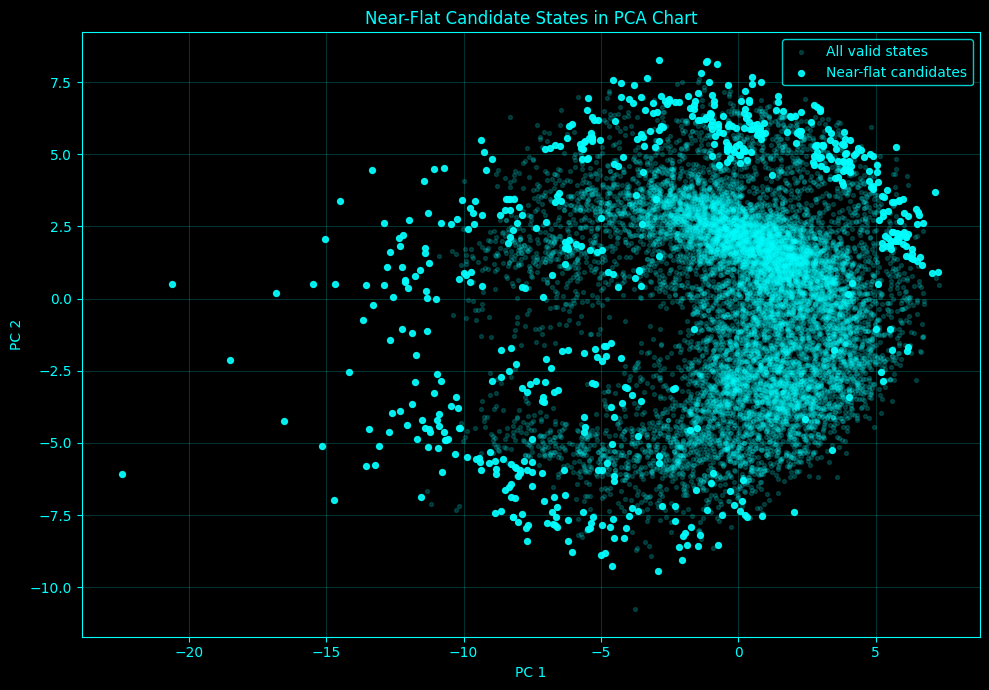

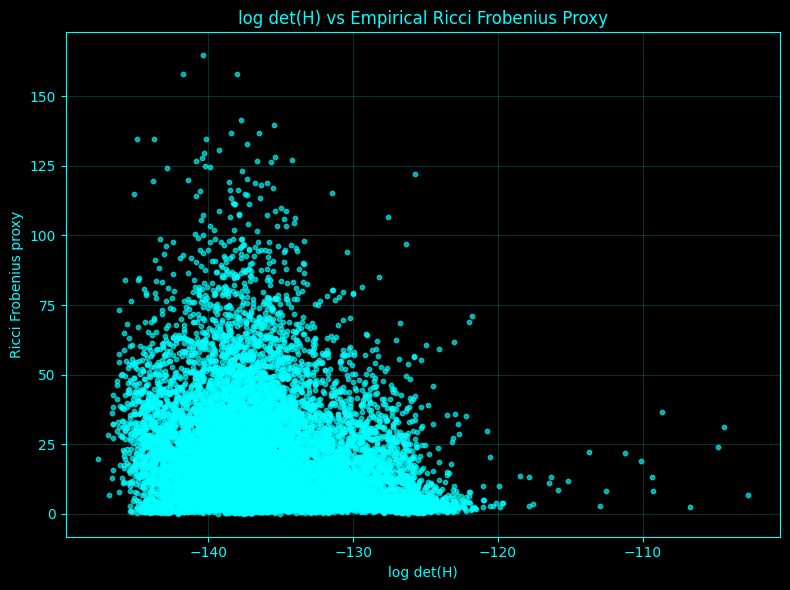


Saved per-state CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/ricci_form_proxy_from_local_hermitian/ricci_form_proxy_per_state.csv
Saved near-flat CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/ricci_form_proxy_from_local_hermitian/ricci_form_proxy_near_flat_states.csv
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/ricci_form_proxy_from_local_hermitian/ricci_form_proxy_summary.csv
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/ricci_form_proxy_from_local_hermitian/ricci_form_proxy_results.npz
Saved summary TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/ricci_form_proxy_from_local_hermitian/ricci_form_proxy_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/ricci_form_proxy_from_local_hermitian/plots


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

in_dir = os.path.join(base_dir, "results", "local_hermitian_metric_field")
plots_dir = os.path.join(in_dir, "plots")
out_dir = os.path.join(base_dir, "results", "ricci_form_proxy_from_local_hermitian")
out_plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(out_plots_dir, exist_ok=True)

npz_path = os.path.join(in_dir, "local_hermitian_metric_field_results.npz")
summary_csv = os.path.join(in_dir, "local_hermitian_metric_field_summary.csv")

# Local fitting controls
k_neighbors = 100          # neighbors in reduced state chart
fit_reg = 1e-8             # tiny stabilization for least-squares logic
min_neighbors = 12         # minimum neighbors required for local quadratic fit

ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def load_inputs(npz_path, summary_csv):
    if not os.path.exists(npz_path):
        raise FileNotFoundError(f"Missing NPZ: {npz_path}")
    if not os.path.exists(summary_csv):
        raise FileNotFoundError(f"Missing summary CSV: {summary_csv}")

    data = np.load(npz_path, allow_pickle=True)
    summary_df = pd.read_csv(summary_csv)

    required_npz = ["pca_xy", "T_sample", "sample_idx", "eeg_channel_names"]
    for key in required_npz:
        if key not in data:
            raise KeyError(f"Missing key '{key}' in {npz_path}")

    pca_xy = np.asarray(data["pca_xy"], dtype=float)
    T_sample = np.asarray(data["T_sample"], dtype=float)
    sample_idx = np.asarray(data["sample_idx"], dtype=int)
    eeg_channel_names = data["eeg_channel_names"]

    if len(summary_df) != len(pca_xy):
        raise ValueError(
            f"Summary CSV row count ({len(summary_df)}) does not match pca_xy length ({len(pca_xy)})."
        )

    needed_cols = ["state_index_subsampled", "time_sec", "logdet_H", "trace_H", "anisotropy_H", "kahler_energy_proxy"]
    for col in needed_cols:
        if col not in summary_df.columns:
            raise KeyError(f"Missing column '{col}' in {summary_csv}")

    return data, summary_df, pca_xy, T_sample, sample_idx, eeg_channel_names

def local_quadratic_ricci_proxy(X2, values, k=100, min_neighbors=12):
    """
    Empirical Ricci-form proxy in a reduced 2D chart.

    We use the Kähler-inspired identity:
        Ric ~ -∂∂̄ log det g

    Since we do not yet have a full complex chart or exact Kähler metric field,
    we approximate the local second variation of:
        f(x, y) = log det H
    over the 2D PCA chart of the analytic EEG state cloud.

    For each point, fit:
        f ≈ a + b x + c y + d x^2 + e x y + f y^2
    in local coordinates centered at the point.

    Then define:
        Hessian = [[2d, e],
                   [ e, 2f]]

    Derived proxies:
        laplacian_proxy = trace(Hessian)
        frobenius_proxy = ||Hessian||_F
        det_proxy = det(Hessian)

    "Ricci-flat-like" regions are those with small ||Hessian||_F and small |trace(Hessian)|.
    """
    X2 = np.asarray(X2, dtype=float)
    values = np.asarray(values, dtype=float)
    n = len(X2)

    tree = cKDTree(X2)
    _, nbr_idx = tree.query(X2, k=min(k + 1, n))

    grad_x = np.full(n, np.nan, dtype=float)
    grad_y = np.full(n, np.nan, dtype=float)

    h_xx = np.full(n, np.nan, dtype=float)
    h_xy = np.full(n, np.nan, dtype=float)
    h_yy = np.full(n, np.nan, dtype=float)

    laplacian = np.full(n, np.nan, dtype=float)
    frob = np.full(n, np.nan, dtype=float)
    detv = np.full(n, np.nan, dtype=float)
    eig_small = np.full(n, np.nan, dtype=float)
    eig_large = np.full(n, np.nan, dtype=float)
    fit_r2 = np.full(n, np.nan, dtype=float)
    mean_neighbor_radius = np.full(n, np.nan, dtype=float)

    for i in range(n):
        idx = np.atleast_1d(nbr_idx[i])
        idx = idx[idx != i]

        good = idx[np.isfinite(values[idx])]
        if len(good) < min_neighbors:
            continue

        Xi = X2[good] - X2[i]
        yi = values[good]

        x = Xi[:, 0]
        y = Xi[:, 1]

        # local quadratic surface
        A = np.column_stack([
            np.ones(len(Xi)),
            x,
            y,
            x * x,
            x * y,
            y * y
        ])

        try:
            coef, *_ = np.linalg.lstsq(A, yi, rcond=None)
        except np.linalg.LinAlgError:
            continue

        y_hat = A @ coef
        ss_res = np.sum((yi - y_hat) ** 2)
        ss_tot = np.sum((yi - np.mean(yi)) ** 2)
        fit_r2[i] = 1.0 - ss_res / (ss_tot + eps)

        # coefficients
        # f = a + b x + c y + d x^2 + e x y + f y^2
        b = coef[1]
        c = coef[2]
        d = coef[3]
        e = coef[4]
        f = coef[5]

        H = np.array([
            [2.0 * d, e],
            [e, 2.0 * f]
        ], dtype=float)

        w = np.linalg.eigvalsh(H)

        grad_x[i] = b
        grad_y[i] = c
        h_xx[i] = H[0, 0]
        h_xy[i] = H[0, 1]
        h_yy[i] = H[1, 1]
        laplacian[i] = np.trace(H)
        frob[i] = np.linalg.norm(H, ord="fro")
        detv[i] = np.linalg.det(H)
        eig_small[i] = w[0]
        eig_large[i] = w[1]
        mean_neighbor_radius[i] = float(np.mean(np.linalg.norm(Xi, axis=1)))

    out = pd.DataFrame({
        "grad_logdet_x": grad_x,
        "grad_logdet_y": grad_y,
        "h_xx_logdet": h_xx,
        "h_xy_logdet": h_xy,
        "h_yy_logdet": h_yy,
        "ricci_laplacian_proxy": laplacian,
        "ricci_frobenius_proxy": frob,
        "ricci_det_proxy": detv,
        "ricci_eig_small": eig_small,
        "ricci_eig_large": eig_large,
        "ricci_fit_r2": fit_r2,
        "ricci_neighbor_radius": mean_neighbor_radius,
    })
    return out

# -------------------------------------------------------
# LOAD PREVIOUS HERMITIAN FIELD RESULTS
# -------------------------------------------------------
data, summary_df, pca_xy, T_sample, sample_idx, eeg_channel_names = load_inputs(npz_path, summary_csv)

print(f"Loaded local Hermitian field summary with {len(summary_df)} sampled states")
print(f"PCA chart shape: {pca_xy.shape}")

# scalar field to differentiate in state space
logdet_H = summary_df["logdet_H"].values.astype(float)

# -------------------------------------------------------
# EMPIRICAL RICCI-FORM PROXY
# -------------------------------------------------------
ricci_df = local_quadratic_ricci_proxy(
    pca_xy,
    logdet_H,
    k=k_neighbors,
    min_neighbors=min_neighbors,
)

full_df = pd.concat(
    [
        summary_df.reset_index(drop=True),
        pd.DataFrame({
            "pca_x": pca_xy[:, 0],
            "pca_y": pca_xy[:, 1],
            "T_sample": T_sample,
            "sample_idx": sample_idx,
        }),
        ricci_df.reset_index(drop=True),
    ],
    axis=1
)

valid_mask = np.isfinite(full_df["ricci_frobenius_proxy"].values)
valid_df = full_df.loc[valid_mask].copy()

if len(valid_df) == 0:
    raise ValueError("No valid Ricci proxy fits were produced. Try lowering k_neighbors or min_neighbors.")

# "Flatness" proxies
valid_df["ricci_abs_laplacian_proxy"] = np.abs(valid_df["ricci_laplacian_proxy"])
valid_df["ricci_flatness_score"] = 1.0 / (1.0 + valid_df["ricci_frobenius_proxy"])
valid_df["ricci_signed_balance"] = valid_df["ricci_laplacian_proxy"] / (
    valid_df["ricci_frobenius_proxy"] + eps
)

# near-flat candidates
flat_thresh = np.percentile(valid_df["ricci_frobenius_proxy"], 10)
lap_thresh = np.percentile(valid_df["ricci_abs_laplacian_proxy"], 10)

near_flat_df = valid_df[
    (valid_df["ricci_frobenius_proxy"] <= flat_thresh) &
    (valid_df["ricci_abs_laplacian_proxy"] <= lap_thresh)
].copy()

# global summaries
summary_row = {
    "n_sampled_states": int(len(full_df)),
    "n_valid_ricci_states": int(len(valid_df)),
    "k_neighbors": int(k_neighbors),
    "min_neighbors": int(min_neighbors),
    "mean_ricci_frobenius_proxy": float(np.mean(valid_df["ricci_frobenius_proxy"])),
    "median_ricci_frobenius_proxy": float(np.median(valid_df["ricci_frobenius_proxy"])),
    "mean_abs_ricci_laplacian_proxy": float(np.mean(valid_df["ricci_abs_laplacian_proxy"])),
    "median_abs_ricci_laplacian_proxy": float(np.median(valid_df["ricci_abs_laplacian_proxy"])),
    "mean_ricci_fit_r2": float(np.mean(valid_df["ricci_fit_r2"])),
    "median_ricci_fit_r2": float(np.median(valid_df["ricci_fit_r2"])),
    "near_flat_count": int(len(near_flat_df)),
    "near_flat_fraction": float(len(near_flat_df) / max(len(valid_df), 1)),
}
summary_out_df = pd.DataFrame([summary_row])

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
full_csv = os.path.join(out_dir, "ricci_form_proxy_per_state.csv")
near_flat_csv = os.path.join(out_dir, "ricci_form_proxy_near_flat_states.csv")
summary_out_csv = os.path.join(out_dir, "ricci_form_proxy_summary.csv")
npz_out = os.path.join(out_dir, "ricci_form_proxy_results.npz")
summary_txt = os.path.join(out_dir, "ricci_form_proxy_summary.txt")

full_df.to_csv(full_csv, index=False)
near_flat_df.to_csv(near_flat_csv, index=False)
summary_out_df.to_csv(summary_out_csv, index=False)

np.savez_compressed(
    npz_out,
    pca_xy=pca_xy,
    T_sample=T_sample,
    sample_idx=sample_idx,
    ricci_frobenius_proxy=full_df["ricci_frobenius_proxy"].values,
    ricci_laplacian_proxy=full_df["ricci_laplacian_proxy"].values,
    ricci_fit_r2=full_df["ricci_fit_r2"].values,
    ricci_flatness_score=valid_df["ricci_flatness_score"].values,
    eeg_channel_names=np.array(eeg_channel_names, dtype=object),
)

with open(summary_txt, "w") as f:
    f.write("Empirical Ricci-form Proxy on the Local Hermitian EEG Manifold\n")
    f.write("=============================================================\n\n")
    f.write("Theory:\n")
    f.write("For a Kähler metric, Ricci curvature is tied to -∂∂̄ log det g.\n")
    f.write("Here we do not yet have a full exact complex metric field in explicit complex charts,\n")
    f.write("so we build an empirical proxy instead.\n\n")
    f.write("Procedure:\n")
    f.write("1. Start from the previously estimated local Hermitian metric field H_i.\n")
    f.write("2. Use the scalar field log det(H_i) on the reduced PCA chart of the analytic EEG state cloud.\n")
    f.write("3. Locally fit a quadratic surface to log det(H) around each state.\n")
    f.write("4. Use the local Hessian of that fit as an empirical Ricci-form / Ricci-flatness proxy.\n\n")
    f.write("Interpretation:\n")
    f.write("- Small Frobenius norm of the Hessian => weak second variation of log det(H).\n")
    f.write("- Small absolute Laplacian proxy => locally flatter scalar-volume geometry.\n")
    f.write("- States that are small in both are 'Ricci-flat-like' candidates in this empirical sense.\n\n")
    f.write(f"Input NPZ: {npz_path}\n")
    f.write(f"Input summary CSV: {summary_csv}\n")
    f.write(f"Sampled states: {len(full_df)}\n")
    f.write(f"Valid local Ricci fits: {len(valid_df)}\n")
    f.write(f"k-neighbors: {k_neighbors}\n")
    f.write(f"min-neighbors: {min_neighbors}\n\n")
    f.write(f"Mean Ricci Frobenius proxy: {summary_row['mean_ricci_frobenius_proxy']:.6f}\n")
    f.write(f"Median Ricci Frobenius proxy: {summary_row['median_ricci_frobenius_proxy']:.6f}\n")
    f.write(f"Mean |Laplacian| proxy: {summary_row['mean_abs_ricci_laplacian_proxy']:.6f}\n")
    f.write(f"Median |Laplacian| proxy: {summary_row['median_abs_ricci_laplacian_proxy']:.6f}\n")
    f.write(f"Mean local quadratic fit R^2: {summary_row['mean_ricci_fit_r2']:.6f}\n")
    f.write(f"Near-flat candidate states: {summary_row['near_flat_count']}\n")
    f.write(f"Near-flat candidate fraction: {summary_row['near_flat_fraction']:.6f}\n\n")

    top_n = min(15, len(near_flat_df))
    if top_n > 0:
        f.write("Top near-flat candidate states:\n")
        cols = ["time_sec", "ricci_frobenius_proxy", "ricci_laplacian_proxy", "ricci_fit_r2", "logdet_H"]
        for _, row in near_flat_df.sort_values("ricci_frobenius_proxy").head(top_n)[cols].iterrows():
            f.write(
                f"  t={row['time_sec']:.6f} sec | "
                f"fro={row['ricci_frobenius_proxy']:.6e} | "
                f"lap={row['ricci_laplacian_proxy']:.6e} | "
                f"R2={row['ricci_fit_r2']:.6f} | "
                f"logdet={row['logdet_H']:.6f}\n"
            )

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------
# 1) PCA state cloud colored by Ricci Frobenius proxy
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    valid_df["pca_x"].values,
    valid_df["pca_y"].values,
    c=valid_df["ricci_frobenius_proxy"].values,
    s=8,
    alpha=0.75
)
ax.set_title("State Cloud PCA Colored by Empirical Ricci Frobenius Proxy")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Ricci Frobenius proxy", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot1_path = os.path.join(out_plots_dir, "ricci_frobenius_proxy_pca.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) PCA state cloud colored by Ricci Laplacian proxy
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    valid_df["pca_x"].values,
    valid_df["pca_y"].values,
    c=valid_df["ricci_laplacian_proxy"].values,
    s=8,
    alpha=0.75
)
ax.set_title("State Cloud PCA Colored by Empirical Ricci Laplacian Proxy")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Ricci Laplacian proxy", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot2_path = os.path.join(out_plots_dir, "ricci_laplacian_proxy_pca.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Ricci proxies over time
fig, axes = plt.subplots(2, 1, figsize=(13, 8), facecolor=BG, sharex=True)
ax1, ax2 = axes
style_ax(ax1)
style_ax(ax2)

ax1.plot(valid_df["time_sec"].values, valid_df["ricci_frobenius_proxy"].values, color=ACCENT, linewidth=1.1)
ax1.axhline(flat_thresh, color=ACCENT, linestyle="--", linewidth=1.0, alpha=0.6)
ax1.set_title("Empirical Ricci Frobenius Proxy Over Time")
ax1.set_ylabel("||Hess(log det H)||_F")

ax2.plot(valid_df["time_sec"].values, valid_df["ricci_abs_laplacian_proxy"].values, color=ACCENT, linewidth=1.1)
ax2.axhline(lap_thresh, color=ACCENT, linestyle="--", linewidth=1.0, alpha=0.6)
ax2.set_title("Absolute Ricci Laplacian Proxy Over Time")
ax2.set_xlabel("Time (sec)")
ax2.set_ylabel("|trace Hess|")

plot3_path = os.path.join(out_plots_dir, "ricci_proxies_over_time.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Histogram of Ricci Frobenius proxy
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
style_ax(ax)

ax.hist(valid_df["ricci_frobenius_proxy"].values, bins=60, color=ACCENT, edgecolor=ACCENT, alpha=0.85)
ax.axvline(flat_thresh, color=ACCENT, linestyle="--", linewidth=1.0, alpha=0.6)
ax.set_title("Distribution of Empirical Ricci Frobenius Proxy")
ax.set_xlabel("Ricci Frobenius proxy")
ax.set_ylabel("Count")

plot4_path = os.path.join(out_plots_dir, "ricci_frobenius_proxy_histogram.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Near-flat candidate states highlighted
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

ax.scatter(
    valid_df["pca_x"].values,
    valid_df["pca_y"].values,
    s=8,
    alpha=0.18,
    color=ACCENT,
    label="All valid states"
)

if len(near_flat_df) > 0:
    ax.scatter(
        near_flat_df["pca_x"].values,
        near_flat_df["pca_y"].values,
        s=18,
        alpha=0.90,
        color=ACCENT,
        label="Near-flat candidates"
    )

ax.set_title("Near-Flat Candidate States in PCA Chart")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.legend()

plot5_path = os.path.join(out_plots_dir, "near_flat_candidate_states.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 6) logdet(H) vs Ricci Frobenius proxy
fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
style_ax(ax)

ax.scatter(
    valid_df["logdet_H"].values,
    valid_df["ricci_frobenius_proxy"].values,
    s=10,
    alpha=0.65,
    color=ACCENT
)
ax.set_title("log det(H) vs Empirical Ricci Frobenius Proxy")
ax.set_xlabel("log det(H)")
ax.set_ylabel("Ricci Frobenius proxy")

plot6_path = os.path.join(out_plots_dir, "logdet_vs_ricci_frobenius_proxy.png")
plt.tight_layout()
plt.savefig(plot6_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved per-state CSV: {full_csv}")
print(f"Saved near-flat CSV: {near_flat_csv}")
print(f"Saved summary CSV: {summary_out_csv}")
print(f"Saved NPZ: {npz_out}")
print(f"Saved summary TXT: {summary_txt}")
print(f"Saved plots to: {out_plots_dir}")

### Density-Filtered Intrinsic Hermitian Basis and Refined Ricci-Form Proxy

Loaded EEG segment: 106944 samples x 32 channels
Sampled states: 12000
Density threshold (q=0.90): 2.730763
Kept states after density filtering: 10800 / 12000


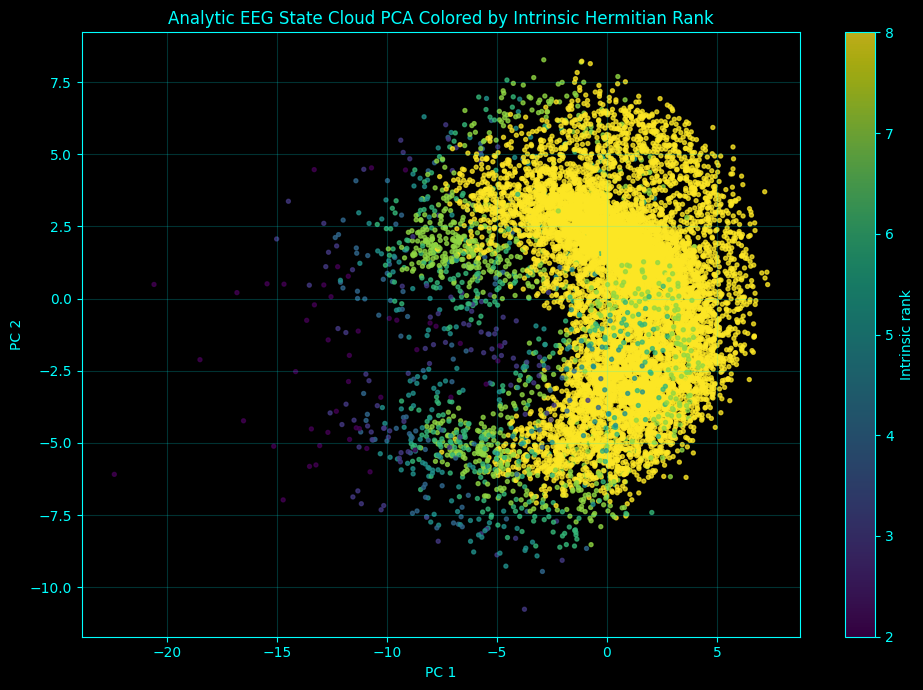

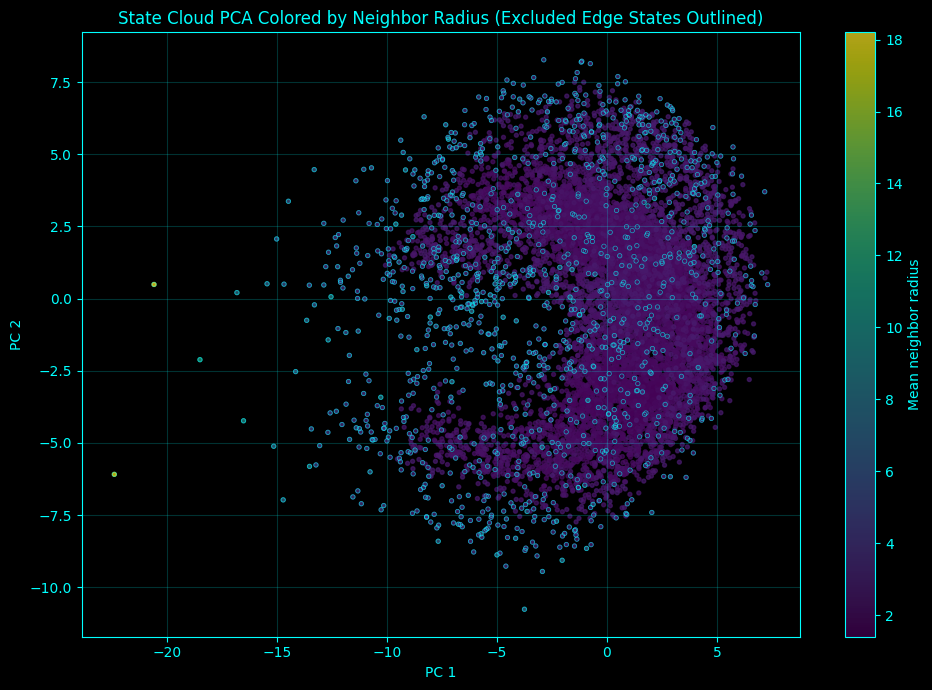

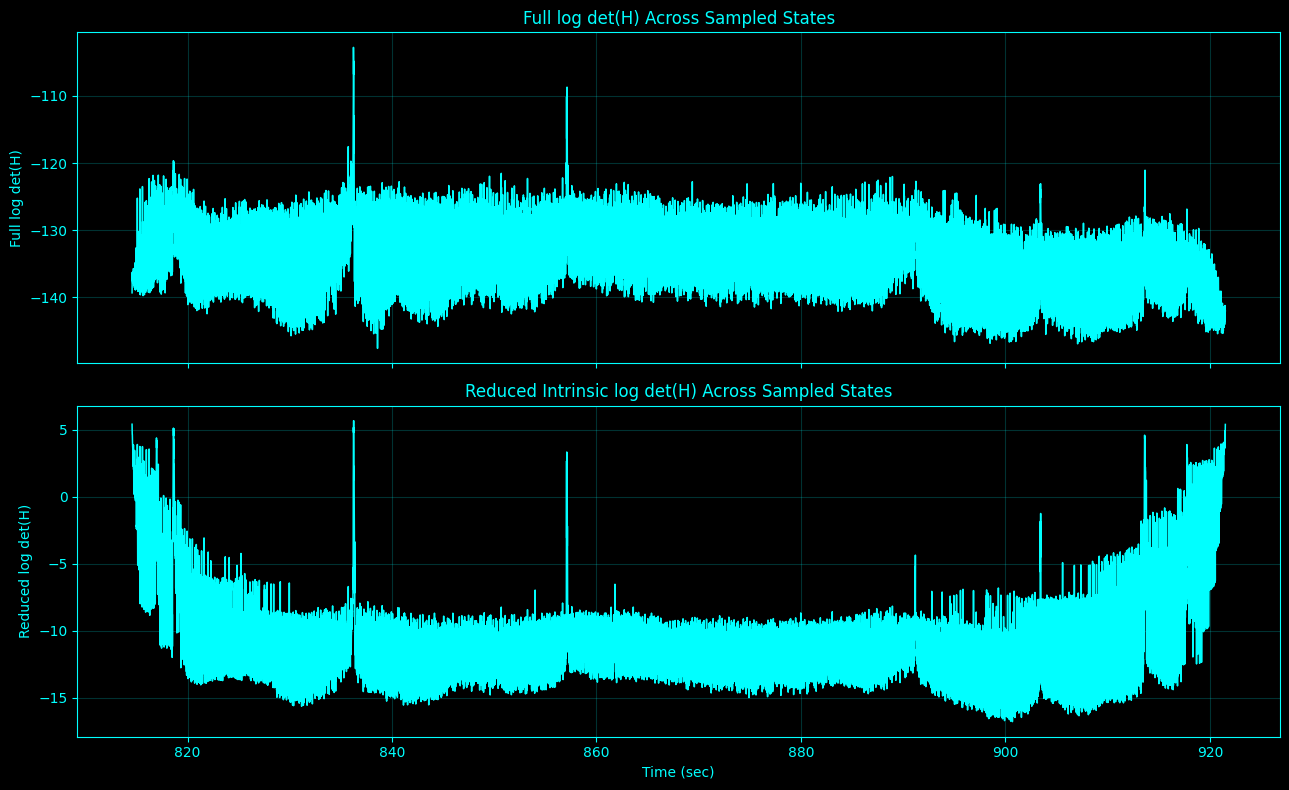

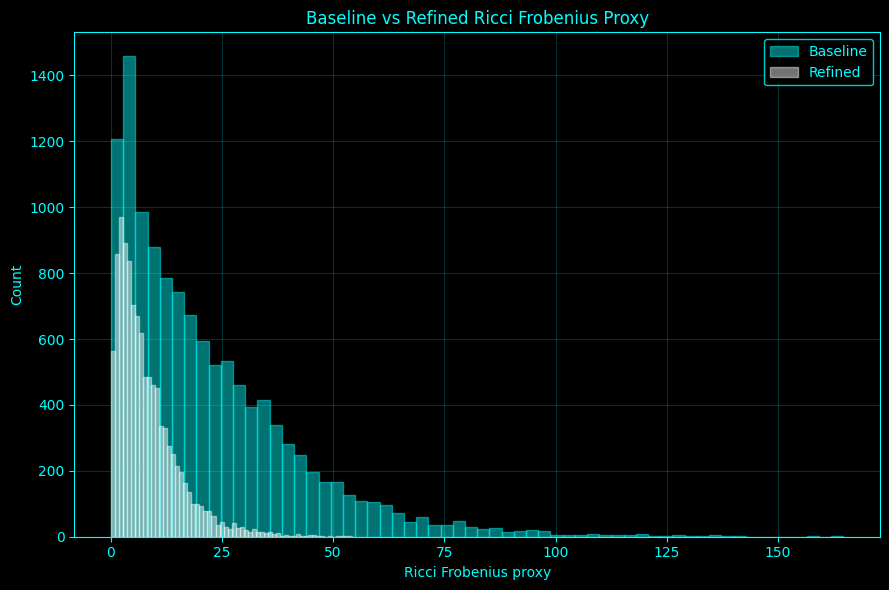

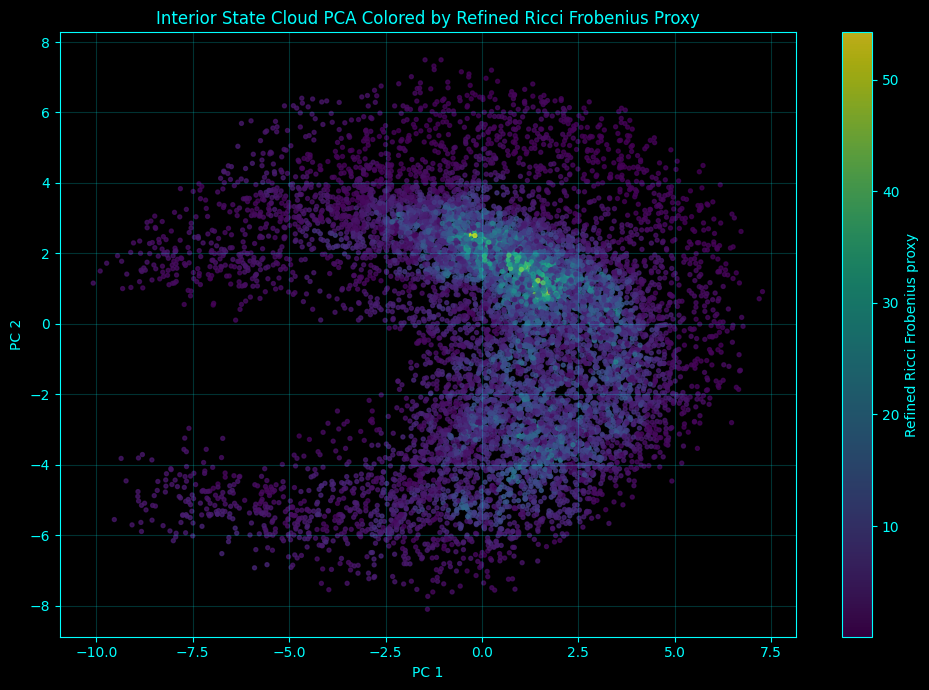

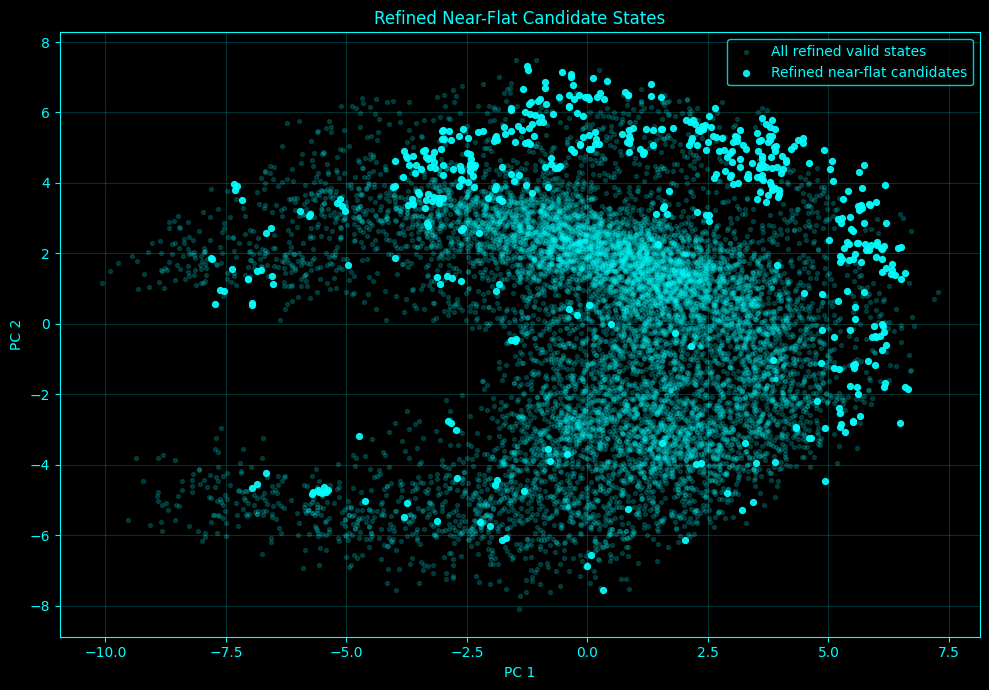


Saved state summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/refined_intrinsic_hermitian_ricci/intrinsic_hermitian_state_summary.csv
Saved baseline Ricci CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/refined_intrinsic_hermitian_ricci/baseline_ricci_proxy_per_state.csv
Saved refined Ricci CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/refined_intrinsic_hermitian_ricci/refined_ricci_proxy_per_state.csv
Saved baseline near-flat CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/refined_intrinsic_hermitian_ricci/baseline_near_flat_states.csv
Saved refined near-flat CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/refined_intrinsic_hermitian_ricci/refined_near_flat_states.csv
Saved comparison CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/refined_intrinsic_hermitian_ricci/baseline_vs_refined_comparison.csv
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/refined_intrinsic_hermitian

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.spatial import cKDTree

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "refined_intrinsic_hermitian_ricci")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
dt = 1.0 / sampling_rate

start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# State-cloud sampling
max_state_points = 12000
rng_seed = 42

# Local Hermitian metric controls
k_metric_neighbors = 80
metric_reg = 1e-6

# Intrinsic basis controls
intrinsic_energy_threshold = 0.90
min_intrinsic_rank = 2
max_intrinsic_rank = 8

# Density filtering
density_keep_quantile = 0.90   # keep states with neighbor radius <= this quantile

# Ricci proxy local fit controls
k_ricci_neighbors = 100
min_fit_neighbors = 12

ACCENT = "cyan"
BG = "black"
eps = 1e-12

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)

    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")

    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T

    raise ValueError(f"Unexpected EEG shape: {x.shape}")

def complex_zscore_by_channel(z):
    z = np.asarray(z, dtype=np.complex128)
    mu = np.mean(z, axis=0, keepdims=True)
    zc = z - mu
    rms = np.sqrt(np.mean(np.abs(zc) ** 2, axis=0, keepdims=True))
    return zc / (rms + eps)

def realify_complex_states(Z):
    return np.concatenate([np.real(Z), np.imag(Z)], axis=1)

def uniform_subsample_indices(n, max_n):
    if max_n is None or n <= max_n:
        return np.arange(n, dtype=int)
    return np.linspace(0, n - 1, max_n).astype(int)

def hermitian_covariance(Z_local, reg=1e-6):
    X = Z_local - np.mean(Z_local, axis=0, keepdims=True)
    L = X.shape[0]
    H = (X.conj().T @ X) / max(L - 1, 1)
    H = 0.5 * (H + H.conj().T)
    H = H + reg * np.eye(H.shape[0], dtype=np.complex128)
    return H

def normalized_eig_entropy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[vals > 0]
    if len(vals) == 0:
        return np.nan
    p = vals / (np.sum(vals) + eps)
    H = -np.sum(p * np.log(p + eps))
    Hmax = np.log(len(p) + eps)
    return float(H / (Hmax + eps))

def participation_ratio(vals):
    vals = np.asarray(vals, dtype=float)
    return float((np.sum(vals) ** 2) / (np.sum(vals ** 2) + eps))

def pca_2d(X):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(len(Xc) - 1, 1)
    w, V = np.linalg.eigh(C)
    idx = np.argsort(w)[::-1][:2]
    Y = Xc @ V[:, idx]
    return Y, w[idx], V[:, idx]

def choose_intrinsic_rank(eigvals_desc, energy_threshold=0.90, min_rank=2, max_rank=8):
    eigvals_desc = np.asarray(eigvals_desc, dtype=float)
    total = np.sum(eigvals_desc)
    if total <= 0:
        return min_rank
    cume = np.cumsum(eigvals_desc) / total
    r = int(np.searchsorted(cume, energy_threshold) + 1)
    r = max(min_rank, r)
    r = min(max_rank, r, len(eigvals_desc))
    return r

def local_quadratic_ricci_proxy(X2, values, k=100, min_neighbors=12):
    """
    Local quadratic fit to a scalar field on a 2D chart:
        f ≈ a + b x + c y + d x^2 + e xy + f y^2

    Hessian proxy:
        [[2d, e],
         [ e, 2f]]
    """
    X2 = np.asarray(X2, dtype=float)
    values = np.asarray(values, dtype=float)
    n = len(X2)

    tree = cKDTree(X2)
    _, nbr_idx = tree.query(X2, k=min(k + 1, n))

    grad_x = np.full(n, np.nan, dtype=float)
    grad_y = np.full(n, np.nan, dtype=float)
    h_xx = np.full(n, np.nan, dtype=float)
    h_xy = np.full(n, np.nan, dtype=float)
    h_yy = np.full(n, np.nan, dtype=float)
    laplacian = np.full(n, np.nan, dtype=float)
    frob = np.full(n, np.nan, dtype=float)
    detv = np.full(n, np.nan, dtype=float)
    eig_small = np.full(n, np.nan, dtype=float)
    eig_large = np.full(n, np.nan, dtype=float)
    fit_r2 = np.full(n, np.nan, dtype=float)
    mean_neighbor_radius = np.full(n, np.nan, dtype=float)

    for i in range(n):
        idx = np.atleast_1d(nbr_idx[i])
        idx = idx[idx != i]

        good = idx[np.isfinite(values[idx])]
        if len(good) < min_neighbors:
            continue

        Xi = X2[good] - X2[i]
        yi = values[good]

        x = Xi[:, 0]
        y = Xi[:, 1]

        A = np.column_stack([
            np.ones(len(Xi)),
            x,
            y,
            x * x,
            x * y,
            y * y
        ])

        try:
            coef, *_ = np.linalg.lstsq(A, yi, rcond=None)
        except np.linalg.LinAlgError:
            continue

        y_hat = A @ coef
        ss_res = np.sum((yi - y_hat) ** 2)
        ss_tot = np.sum((yi - np.mean(yi)) ** 2)
        fit_r2[i] = 1.0 - ss_res / (ss_tot + eps)

        b = coef[1]
        c = coef[2]
        d = coef[3]
        e = coef[4]
        f = coef[5]

        H = np.array([
            [2.0 * d, e],
            [e, 2.0 * f]
        ], dtype=float)

        w = np.linalg.eigvalsh(H)

        grad_x[i] = b
        grad_y[i] = c
        h_xx[i] = H[0, 0]
        h_xy[i] = H[0, 1]
        h_yy[i] = H[1, 1]
        laplacian[i] = np.trace(H)
        frob[i] = np.linalg.norm(H, ord="fro")
        detv[i] = np.linalg.det(H)
        eig_small[i] = w[0]
        eig_large[i] = w[1]
        mean_neighbor_radius[i] = float(np.mean(np.linalg.norm(Xi, axis=1)))

    return pd.DataFrame({
        "grad_x": grad_x,
        "grad_y": grad_y,
        "h_xx": h_xx,
        "h_xy": h_xy,
        "h_yy": h_yy,
        "ricci_laplacian_proxy": laplacian,
        "ricci_frobenius_proxy": frob,
        "ricci_det_proxy": detv,
        "ricci_eig_small": eig_small,
        "ricci_eig_large": eig_large,
        "ricci_fit_r2": fit_r2,
        "ricci_neighbor_radius": mean_neighbor_radius,
    })

# -------------------------------------------------------
# LOAD EEG AND BUILD ANALYTIC STATE CLOUD
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channel_names))
EEG_segment = EEG_data[start_index:end_index, :]

n_samples, n_channels = EEG_segment.shape
time_sec = start_time + np.arange(n_samples) * dt

analytic_EEG = hilbert(EEG_segment, axis=0)
analytic_EEG = complex_zscore_by_channel(analytic_EEG)

sample_idx = uniform_subsample_indices(n_samples, max_state_points)
Z_sample = analytic_EEG[sample_idx, :]
T_sample = time_sec[sample_idx]
X_real = realify_complex_states(Z_sample)

pca_xy, pca_eigs, _ = pca_2d(X_real)

print(f"Loaded EEG segment: {n_samples} samples x {n_channels} channels")
print(f"Sampled states: {len(sample_idx)}")

# -------------------------------------------------------
# LOCAL HERMITIAN METRIC FIELD
# -------------------------------------------------------
tree = cKDTree(X_real)
_, nbr_idx = tree.query(X_real, k=min(k_metric_neighbors + 1, len(X_real)))

state_rows = []

for i in range(len(X_real)):
    idx = np.atleast_1d(nbr_idx[i])
    idx = idx[idx != i]
    if len(idx) < 3:
        idx = np.atleast_1d(nbr_idx[i])

    Z_local = Z_sample[idx, :]
    H = hermitian_covariance(Z_local, reg=metric_reg)

    eigvals = np.linalg.eigvalsh(H)
    eigvals = np.maximum(np.real(eigvals), metric_reg)
    eigvals_desc = eigvals[::-1]

    intrinsic_rank = choose_intrinsic_rank(
        eigvals_desc,
        energy_threshold=intrinsic_energy_threshold,
        min_rank=min_intrinsic_rank,
        max_rank=max_intrinsic_rank
    )

    full_logdet = float(np.sum(np.log(eigvals + eps)))
    reduced_logdet = float(np.sum(np.log(eigvals_desc[:intrinsic_rank] + eps)))
    full_trace = float(np.sum(eigvals))
    reduced_trace = float(np.sum(eigvals_desc[:intrinsic_rank]))

    full_anisotropy = float((eigvals_desc[0] - eigvals_desc[-1]) / (eigvals_desc[0] + eigvals_desc[-1] + eps))
    reduced_anisotropy = float((eigvals_desc[0] - eigvals_desc[intrinsic_rank - 1]) / (eigvals_desc[0] + eigvals_desc[intrinsic_rank - 1] + eps))

    mean_neighbor_radius = float(np.mean(np.linalg.norm(X_real[idx] - X_real[i], axis=1)))

    state_rows.append({
        "state_index_original": int(sample_idx[i]),
        "state_index_subsampled": int(i),
        "time_sec": float(T_sample[i]),
        "full_logdet_H": full_logdet,
        "reduced_logdet_H": reduced_logdet,
        "full_trace_H": full_trace,
        "reduced_trace_H": reduced_trace,
        "full_anisotropy_H": full_anisotropy,
        "reduced_anisotropy_H": reduced_anisotropy,
        "intrinsic_rank": int(intrinsic_rank),
        "eig_entropy_H": normalized_eig_entropy(eigvals_desc),
        "participation_ratio_H": participation_ratio(eigvals_desc),
        "mean_neighbor_radius": mean_neighbor_radius,
    })

state_df = pd.DataFrame(state_rows)

# -------------------------------------------------------
# DENSITY FILTER
# -------------------------------------------------------
radius_threshold = float(np.quantile(state_df["mean_neighbor_radius"].values, density_keep_quantile))
density_mask = state_df["mean_neighbor_radius"].values <= radius_threshold
state_df["density_kept"] = density_mask.astype(int)

kept_df = state_df.loc[density_mask].copy().reset_index(drop=True)
pca_xy_kept = pca_xy[density_mask]

print(f"Density threshold (q={density_keep_quantile:.2f}): {radius_threshold:.6f}")
print(f"Kept states after density filtering: {len(kept_df)} / {len(state_df)}")

# -------------------------------------------------------
# BASELINE RICCI PROXY
# -------------------------------------------------------
baseline_ricci = local_quadratic_ricci_proxy(
    pca_xy,
    state_df["full_logdet_H"].values,
    k=k_ricci_neighbors,
    min_neighbors=min_fit_neighbors
)

baseline_df = pd.concat(
    [
        state_df.reset_index(drop=True),
        pd.DataFrame({
            "pca_x": pca_xy[:, 0],
            "pca_y": pca_xy[:, 1],
        }),
        baseline_ricci.reset_index(drop=True),
    ],
    axis=1
)

baseline_valid = baseline_df[np.isfinite(baseline_df["ricci_frobenius_proxy"])].copy()
baseline_valid["ricci_abs_laplacian_proxy"] = np.abs(baseline_valid["ricci_laplacian_proxy"])
baseline_valid["ricci_flatness_score"] = 1.0 / (1.0 + baseline_valid["ricci_frobenius_proxy"])

# -------------------------------------------------------
# REFINED RICCI PROXY
# -------------------------------------------------------
refined_ricci = local_quadratic_ricci_proxy(
    pca_xy_kept,
    kept_df["reduced_logdet_H"].values,
    k=min(k_ricci_neighbors, max(len(kept_df) - 1, 2)),
    min_neighbors=min_fit_neighbors
)

refined_df = pd.concat(
    [
        kept_df.reset_index(drop=True),
        pd.DataFrame({
            "pca_x": pca_xy_kept[:, 0],
            "pca_y": pca_xy_kept[:, 1],
        }),
        refined_ricci.reset_index(drop=True),
    ],
    axis=1
)

refined_valid = refined_df[np.isfinite(refined_df["ricci_frobenius_proxy"])].copy()
refined_valid["ricci_abs_laplacian_proxy"] = np.abs(refined_valid["ricci_laplacian_proxy"])
refined_valid["ricci_flatness_score"] = 1.0 / (1.0 + refined_valid["ricci_frobenius_proxy"])

# -------------------------------------------------------
# NEAR-FLAT CANDIDATES
# -------------------------------------------------------
baseline_frob_thresh = float(np.quantile(baseline_valid["ricci_frobenius_proxy"], 0.10))
baseline_lap_thresh = float(np.quantile(baseline_valid["ricci_abs_laplacian_proxy"], 0.10))
baseline_near_flat = baseline_valid[
    (baseline_valid["ricci_frobenius_proxy"] <= baseline_frob_thresh) &
    (baseline_valid["ricci_abs_laplacian_proxy"] <= baseline_lap_thresh)
].copy()

refined_frob_thresh = float(np.quantile(refined_valid["ricci_frobenius_proxy"], 0.10))
refined_lap_thresh = float(np.quantile(refined_valid["ricci_abs_laplacian_proxy"], 0.10))
refined_near_flat = refined_valid[
    (refined_valid["ricci_frobenius_proxy"] <= refined_frob_thresh) &
    (refined_valid["ricci_abs_laplacian_proxy"] <= refined_lap_thresh)
].copy()

# -------------------------------------------------------
# COMPARISON SUMMARY
# -------------------------------------------------------
comparison_rows = [
    {
        "pipeline": "baseline_full_all_states",
        "n_states_input": int(len(state_df)),
        "n_states_valid_fit": int(len(baseline_valid)),
        "mean_intrinsic_rank": float(np.mean(state_df["intrinsic_rank"])),
        "median_intrinsic_rank": float(np.median(state_df["intrinsic_rank"])),
        "mean_neighbor_radius": float(np.mean(state_df["mean_neighbor_radius"])),
        "mean_logdet_used": float(np.mean(state_df["full_logdet_H"])),
        "mean_ricci_frobenius_proxy": float(np.mean(baseline_valid["ricci_frobenius_proxy"])),
        "median_ricci_frobenius_proxy": float(np.median(baseline_valid["ricci_frobenius_proxy"])),
        "mean_abs_ricci_laplacian_proxy": float(np.mean(baseline_valid["ricci_abs_laplacian_proxy"])),
        "median_abs_ricci_laplacian_proxy": float(np.median(baseline_valid["ricci_abs_laplacian_proxy"])),
        "mean_fit_r2": float(np.mean(baseline_valid["ricci_fit_r2"])),
        "median_fit_r2": float(np.median(baseline_valid["ricci_fit_r2"])),
        "near_flat_count": int(len(baseline_near_flat)),
        "near_flat_fraction": float(len(baseline_near_flat) / max(len(baseline_valid), 1)),
    },
    {
        "pipeline": "refined_reduced_density_filtered",
        "n_states_input": int(len(kept_df)),
        "n_states_valid_fit": int(len(refined_valid)),
        "mean_intrinsic_rank": float(np.mean(kept_df["intrinsic_rank"])),
        "median_intrinsic_rank": float(np.median(kept_df["intrinsic_rank"])),
        "mean_neighbor_radius": float(np.mean(kept_df["mean_neighbor_radius"])),
        "mean_logdet_used": float(np.mean(kept_df["reduced_logdet_H"])),
        "mean_ricci_frobenius_proxy": float(np.mean(refined_valid["ricci_frobenius_proxy"])),
        "median_ricci_frobenius_proxy": float(np.median(refined_valid["ricci_frobenius_proxy"])),
        "mean_abs_ricci_laplacian_proxy": float(np.mean(refined_valid["ricci_abs_laplacian_proxy"])),
        "median_abs_ricci_laplacian_proxy": float(np.median(refined_valid["ricci_abs_laplacian_proxy"])),
        "mean_fit_r2": float(np.mean(refined_valid["ricci_fit_r2"])),
        "median_fit_r2": float(np.median(refined_valid["ricci_fit_r2"])),
        "near_flat_count": int(len(refined_near_flat)),
        "near_flat_fraction": float(len(refined_near_flat) / max(len(refined_valid), 1)),
    }
]
comparison_df = pd.DataFrame(comparison_rows)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
state_csv = os.path.join(out_dir, "intrinsic_hermitian_state_summary.csv")
baseline_csv = os.path.join(out_dir, "baseline_ricci_proxy_per_state.csv")
refined_csv = os.path.join(out_dir, "refined_ricci_proxy_per_state.csv")
baseline_flat_csv = os.path.join(out_dir, "baseline_near_flat_states.csv")
refined_flat_csv = os.path.join(out_dir, "refined_near_flat_states.csv")
comparison_csv = os.path.join(out_dir, "baseline_vs_refined_comparison.csv")
npz_path = os.path.join(out_dir, "refined_intrinsic_hermitian_ricci_results.npz")
summary_txt = os.path.join(out_dir, "refined_intrinsic_hermitian_ricci_summary.txt")

state_df.to_csv(state_csv, index=False)
baseline_df.to_csv(baseline_csv, index=False)
refined_df.to_csv(refined_csv, index=False)
baseline_near_flat.to_csv(baseline_flat_csv, index=False)
refined_near_flat.to_csv(refined_flat_csv, index=False)
comparison_df.to_csv(comparison_csv, index=False)

np.savez_compressed(
    npz_path,
    sample_idx=sample_idx,
    T_sample=T_sample,
    pca_xy=pca_xy,
    density_mask=density_mask,
    baseline_ricci_frobenius_proxy=baseline_df["ricci_frobenius_proxy"].values,
    refined_ricci_frobenius_proxy=refined_df["ricci_frobenius_proxy"].values,
    baseline_ricci_laplacian_proxy=baseline_df["ricci_laplacian_proxy"].values,
    refined_ricci_laplacian_proxy=refined_df["ricci_laplacian_proxy"].values,
    intrinsic_rank=state_df["intrinsic_rank"].values,
    mean_neighbor_radius=state_df["mean_neighbor_radius"].values,
    eeg_channel_names=np.array(eeg_channel_names, dtype=object),
)

with open(summary_txt, "w") as f:
    f.write("Density-Filtered Intrinsic Hermitian Basis and Refined Ricci-Form Proxy\n")
    f.write("======================================================================\n\n")
    f.write("Goal:\n")
    f.write("Refine the Hermitian-geometry pipeline before any stronger Calabi–Yau-like interpretation.\n\n")
    f.write("Procedure:\n")
    f.write("1. Build local Hermitian metrics H_i on the analytic EEG state cloud.\n")
    f.write("2. Estimate an intrinsic rank at each state from the local Hermitian spectrum.\n")
    f.write("3. Replace full log det(H_i) with a reduced intrinsic logdet using only dominant directions.\n")
    f.write("4. Remove low-density / boundary states using neighbor-radius filtering.\n")
    f.write("5. Recompute the Ricci proxy on the reduced intrinsic basis over the interior state cloud.\n\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampled states: {len(state_df)}\n")
    f.write(f"k_metric_neighbors: {k_metric_neighbors}\n")
    f.write(f"k_ricci_neighbors: {k_ricci_neighbors}\n")
    f.write(f"intrinsic_energy_threshold: {intrinsic_energy_threshold}\n")
    f.write(f"intrinsic rank bounds: [{min_intrinsic_rank}, {max_intrinsic_rank}]\n")
    f.write(f"density_keep_quantile: {density_keep_quantile}\n")
    f.write(f"density radius threshold: {radius_threshold:.6f}\n\n")

    for _, row in comparison_df.iterrows():
        f.write(
            f"{row['pipeline']}:\n"
            f"  n_states_input = {int(row['n_states_input'])}\n"
            f"  n_states_valid_fit = {int(row['n_states_valid_fit'])}\n"
            f"  mean_intrinsic_rank = {row['mean_intrinsic_rank']:.6f}\n"
            f"  median_intrinsic_rank = {row['median_intrinsic_rank']:.6f}\n"
            f"  mean_neighbor_radius = {row['mean_neighbor_radius']:.6f}\n"
            f"  mean_logdet_used = {row['mean_logdet_used']:.6f}\n"
            f"  mean_ricci_frobenius_proxy = {row['mean_ricci_frobenius_proxy']:.6f}\n"
            f"  median_ricci_frobenius_proxy = {row['median_ricci_frobenius_proxy']:.6f}\n"
            f"  mean_abs_ricci_laplacian_proxy = {row['mean_abs_ricci_laplacian_proxy']:.6f}\n"
            f"  median_abs_ricci_laplacian_proxy = {row['median_abs_ricci_laplacian_proxy']:.6f}\n"
            f"  mean_fit_r2 = {row['mean_fit_r2']:.6f}\n"
            f"  median_fit_r2 = {row['median_fit_r2']:.6f}\n"
            f"  near_flat_count = {int(row['near_flat_count'])}\n"
            f"  near_flat_fraction = {row['near_flat_fraction']:.6f}\n\n"
        )

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------
# 1) PCA chart colored by intrinsic rank
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    pca_xy[:, 0],
    pca_xy[:, 1],
    c=state_df["intrinsic_rank"].values,
    s=8,
    alpha=0.75
)
ax.set_title("Analytic EEG State Cloud PCA Colored by Intrinsic Hermitian Rank")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Intrinsic rank", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot1_path = os.path.join(plots_dir, "pca_intrinsic_rank.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) PCA chart colored by mean neighbor radius with excluded states highlighted
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    pca_xy[:, 0],
    pca_xy[:, 1],
    c=state_df["mean_neighbor_radius"].values,
    s=8,
    alpha=0.70
)

excluded = ~density_mask
if np.any(excluded):
    ax.scatter(
        pca_xy[excluded, 0],
        pca_xy[excluded, 1],
        s=10,
        facecolors="none",
        edgecolors=ACCENT,
        alpha=0.65,
        linewidths=0.5
    )

ax.set_title("State Cloud PCA Colored by Neighbor Radius (Excluded Edge States Outlined)")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Mean neighbor radius", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot2_path = os.path.join(plots_dir, "pca_neighbor_radius_density_filter.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Full vs reduced logdet over sampled states
fig, axes = plt.subplots(2, 1, figsize=(13, 8), facecolor=BG, sharex=True)
ax1, ax2 = axes
style_ax(ax1)
style_ax(ax2)

ax1.plot(state_df["time_sec"].values, state_df["full_logdet_H"].values, color=ACCENT, linewidth=1.1)
ax1.set_title("Full log det(H) Across Sampled States")
ax1.set_ylabel("Full log det(H)")

ax2.plot(state_df["time_sec"].values, state_df["reduced_logdet_H"].values, color=ACCENT, linewidth=1.1)
ax2.set_title("Reduced Intrinsic log det(H) Across Sampled States")
ax2.set_xlabel("Time (sec)")
ax2.set_ylabel("Reduced log det(H)")

plot3_path = os.path.join(plots_dir, "full_vs_reduced_logdet_over_time.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Baseline vs refined Ricci Frobenius distributions
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

ax.hist(
    baseline_valid["ricci_frobenius_proxy"].values,
    bins=60,
    alpha=0.45,
    color=ACCENT,
    edgecolor=ACCENT,
    label="Baseline"
)
ax.hist(
    refined_valid["ricci_frobenius_proxy"].values,
    bins=60,
    alpha=0.45,
    color="white",
    edgecolor="white",
    label="Refined"
)
ax.set_title("Baseline vs Refined Ricci Frobenius Proxy")
ax.set_xlabel("Ricci Frobenius proxy")
ax.set_ylabel("Count")
ax.legend()

plot4_path = os.path.join(plots_dir, "baseline_vs_refined_ricci_frobenius_hist.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Refined Ricci Frobenius proxy on interior state cloud
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    refined_valid["pca_x"].values,
    refined_valid["pca_y"].values,
    c=refined_valid["ricci_frobenius_proxy"].values,
    s=8,
    alpha=0.75
)
ax.set_title("Interior State Cloud PCA Colored by Refined Ricci Frobenius Proxy")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Refined Ricci Frobenius proxy", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot5_path = os.path.join(plots_dir, "refined_ricci_frobenius_pca.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 6) Refined near-flat candidates highlighted
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

ax.scatter(
    refined_valid["pca_x"].values,
    refined_valid["pca_y"].values,
    s=8,
    alpha=0.18,
    color=ACCENT,
    label="All refined valid states"
)

if len(refined_near_flat) > 0:
    ax.scatter(
        refined_near_flat["pca_x"].values,
        refined_near_flat["pca_y"].values,
        s=18,
        alpha=0.90,
        color=ACCENT,
        label="Refined near-flat candidates"
    )

ax.set_title("Refined Near-Flat Candidate States")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.legend()

plot6_path = os.path.join(plots_dir, "refined_near_flat_candidates.png")
plt.tight_layout()
plt.savefig(plot6_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved state summary CSV: {state_csv}")
print(f"Saved baseline Ricci CSV: {baseline_csv}")
print(f"Saved refined Ricci CSV: {refined_csv}")
print(f"Saved baseline near-flat CSV: {baseline_flat_csv}")
print(f"Saved refined near-flat CSV: {refined_flat_csv}")
print(f"Saved comparison CSV: {comparison_csv}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved summary TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

### Banach manifold

Loaded EEG segment: 106944 samples x 32 channels
Sampled states: 12000
Density threshold (q=0.90): 5.325444
Kept states after density filtering: 10800 / 12000


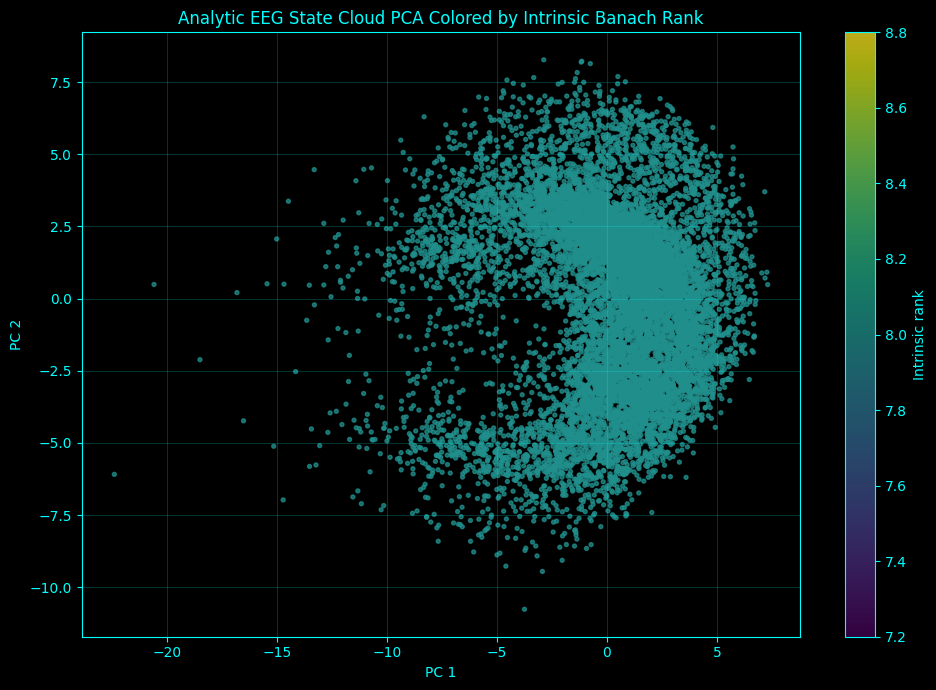

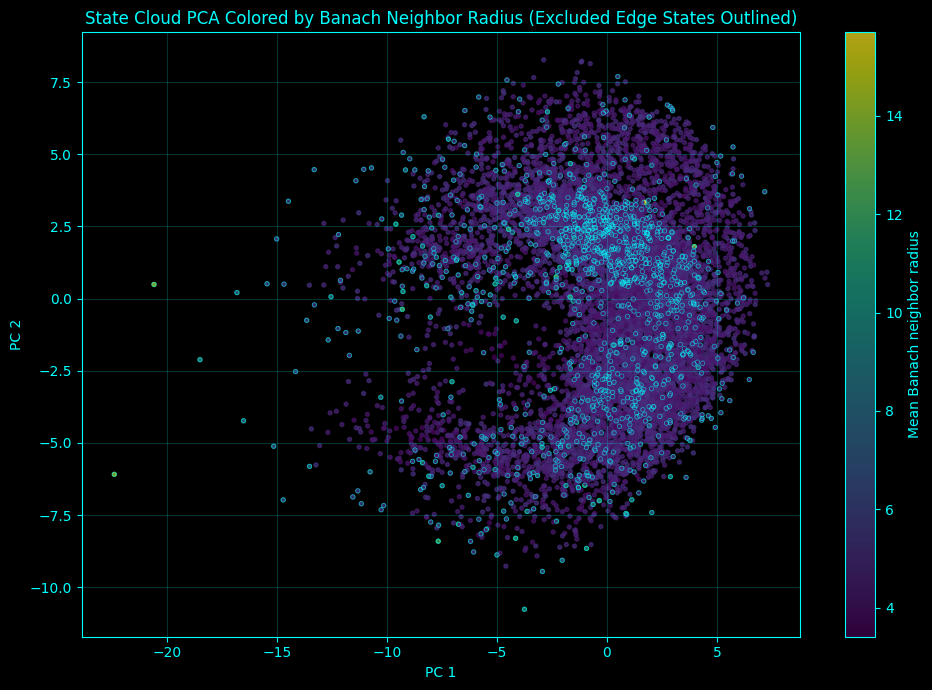

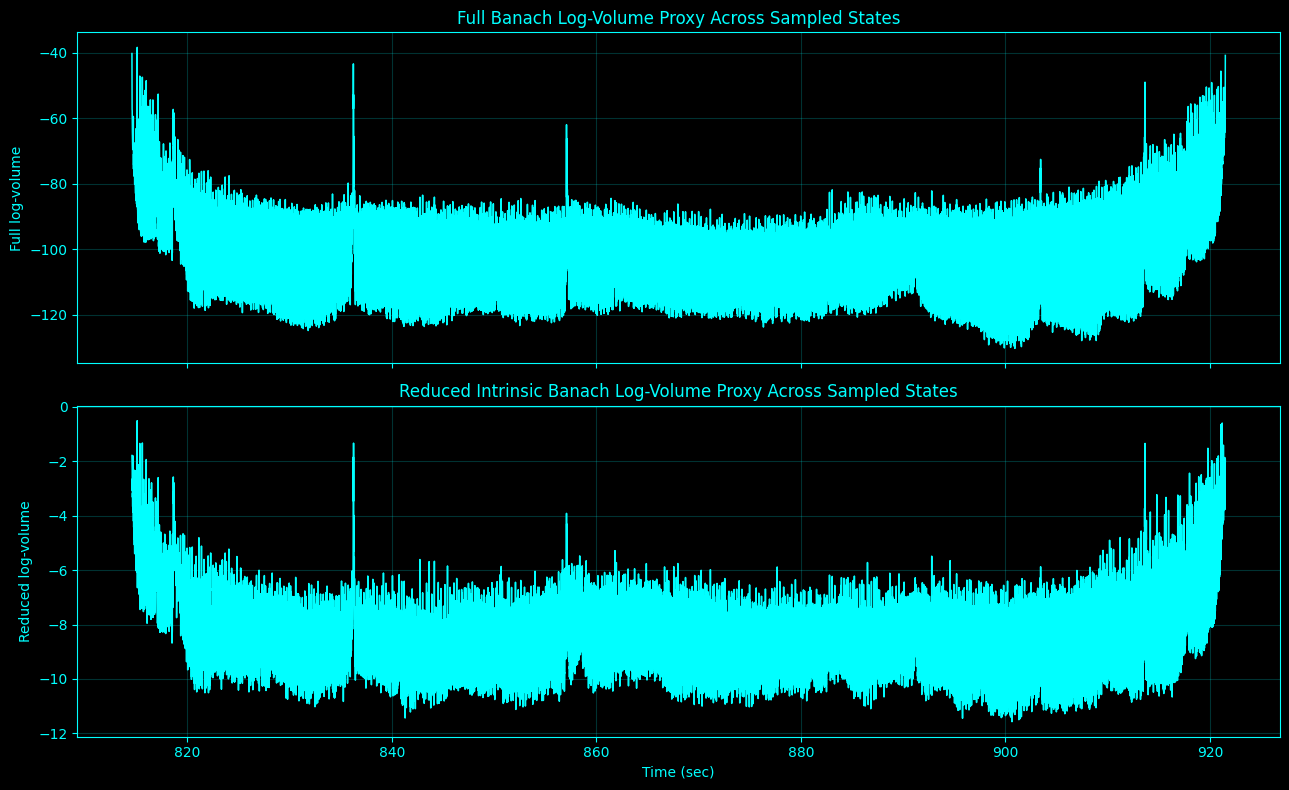

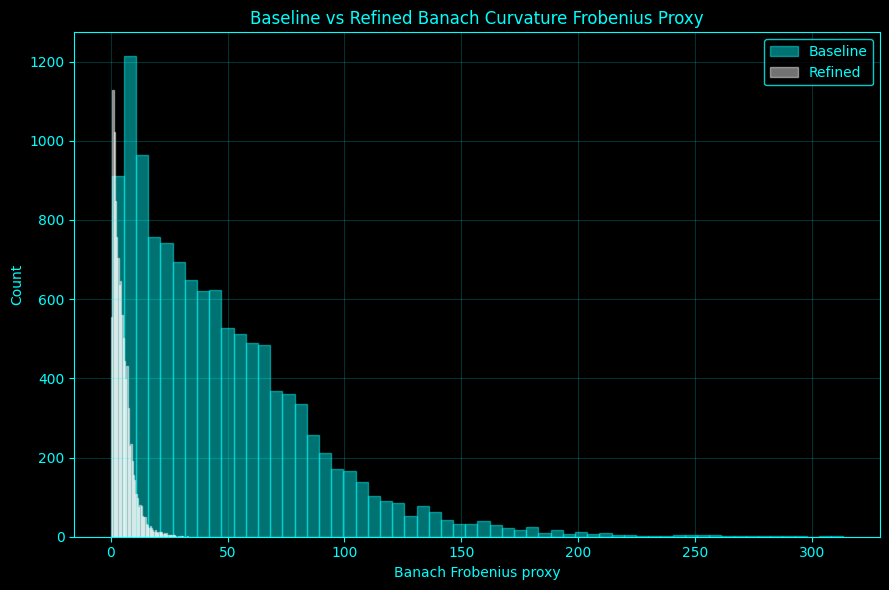

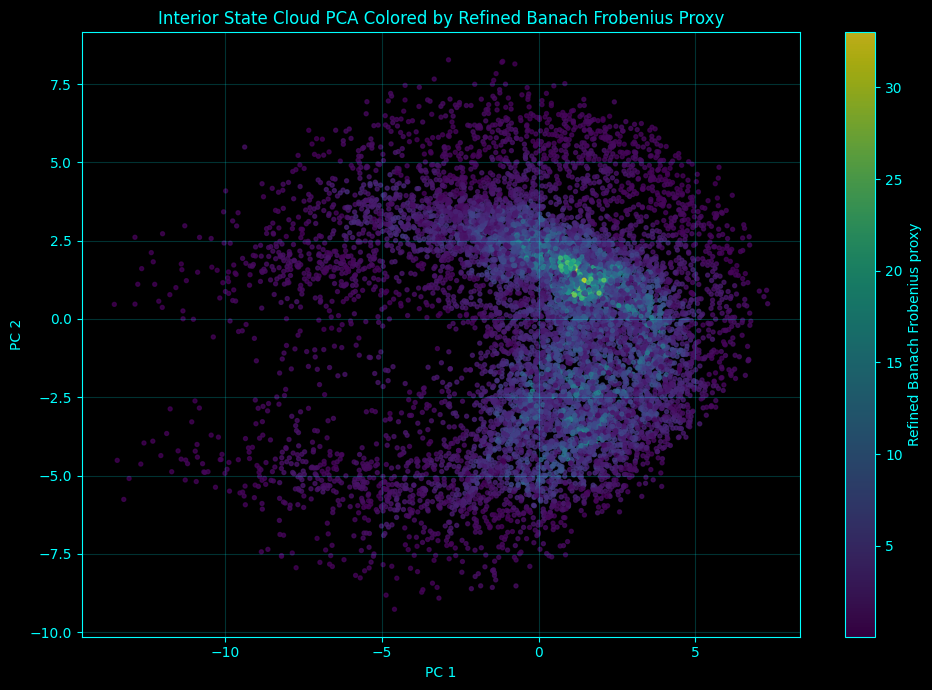

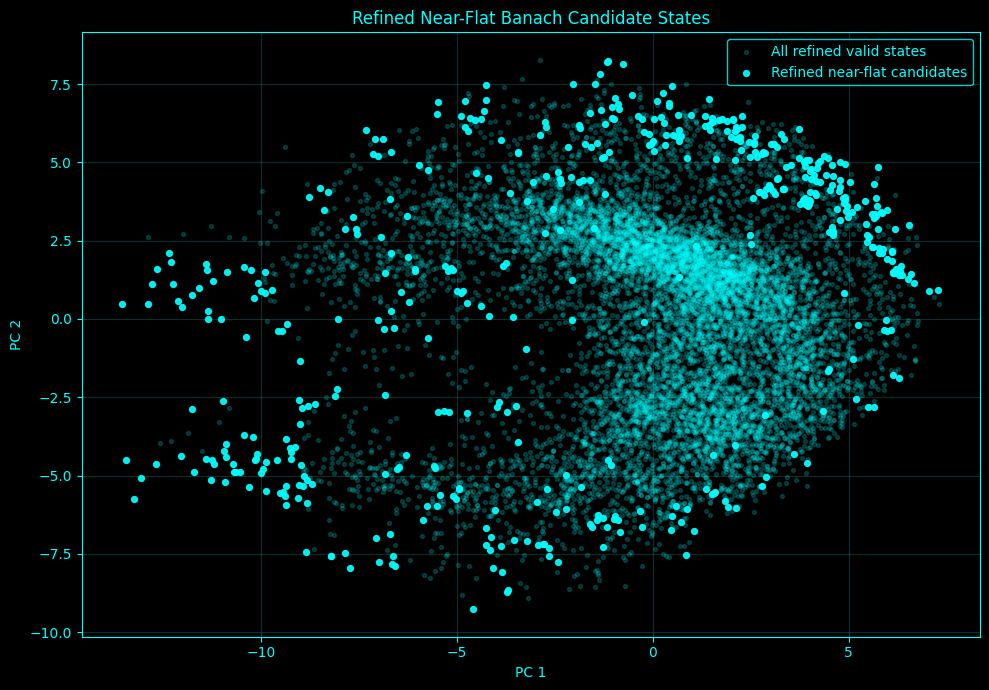


Saved state summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/banach_intrinsic_curvature/banach_state_summary.csv
Saved baseline Banach curvature CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/banach_intrinsic_curvature/baseline_banach_curvature_per_state.csv
Saved refined Banach curvature CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/banach_intrinsic_curvature/refined_banach_curvature_per_state.csv
Saved baseline near-flat CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/banach_intrinsic_curvature/baseline_banach_near_flat_states.csv
Saved refined near-flat CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/banach_intrinsic_curvature/refined_banach_near_flat_states.csv
Saved comparison CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/banach_intrinsic_curvature/baseline_vs_refined_banach_comparison.csv
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/banach_intrinsic_curvature/ba

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.spatial import cKDTree

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "banach_intrinsic_curvature")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
dt = 1.0 / sampling_rate

start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# State-cloud sampling
max_state_points = 12000
rng_seed = 42

# Local neighborhood controls
k_metric_neighbors = 80
scale_reg = 1e-6

# Intrinsic basis controls
intrinsic_energy_threshold = 0.90
min_intrinsic_rank = 2
max_intrinsic_rank = 8

# Density filtering
density_keep_quantile = 0.90   # keep states with Banach neighbor radius <= this quantile

# Local scalar curvature-proxy fit controls
k_curvature_neighbors = 100
min_fit_neighbors = 12

# Banach / Finsler-style local norm controls
banach_p = 4.0                 # p != 2 moves away from Hilbert geometry
scale_method = "mad"           # "mad" or "rms"

ACCENT = "cyan"
BG = "black"
eps = 1e-12

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)

    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")

    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T

    raise ValueError(f"Unexpected EEG shape: {x.shape}")

def complex_zscore_by_channel(z):
    z = np.asarray(z, dtype=np.complex128)
    mu = np.mean(z, axis=0, keepdims=True)
    zc = z - mu
    rms = np.sqrt(np.mean(np.abs(zc) ** 2, axis=0, keepdims=True))
    return zc / (rms + eps)

def realify_complex_states(Z):
    return np.concatenate([np.real(Z), np.imag(Z)], axis=1)

def uniform_subsample_indices(n, max_n):
    if max_n is None or n <= max_n:
        return np.arange(n, dtype=int)
    return np.linspace(0, n - 1, max_n).astype(int)

def normalized_eig_entropy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[vals > 0]
    if len(vals) == 0:
        return np.nan
    p = vals / (np.sum(vals) + eps)
    H = -np.sum(p * np.log(p + eps))
    Hmax = np.log(len(p) + eps)
    return float(H / (Hmax + eps))

def participation_ratio(vals):
    vals = np.asarray(vals, dtype=float)
    return float((np.sum(vals) ** 2) / (np.sum(vals ** 2) + eps))

def pca_2d(X):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(len(Xc) - 1, 1)
    w, V = np.linalg.eigh(C)
    idx = np.argsort(w)[::-1][:2]
    Y = Xc @ V[:, idx]
    return Y, w[idx], V[:, idx]

def choose_intrinsic_rank(eigvals_desc, energy_threshold=0.90, min_rank=2, max_rank=8):
    eigvals_desc = np.asarray(eigvals_desc, dtype=float)
    total = np.sum(eigvals_desc)
    if total <= 0:
        return min_rank
    cume = np.cumsum(eigvals_desc) / total
    r = int(np.searchsorted(cume, energy_threshold) + 1)
    r = max(min_rank, r)
    r = min(max_rank, r, len(eigvals_desc))
    return r

def local_coordinate_scales(X_local, reg=1e-6, method="mad"):
    """
    Robust local coordinate scales for a weighted L^p norm field.
    """
    X_local = np.asarray(X_local, dtype=float)

    if X_local.ndim != 2:
        raise ValueError(f"Expected 2D local offsets, got shape {X_local.shape}")
    if X_local.shape[0] == 0:
        raise ValueError("Empty local neighborhood")

    if method == "mad":
        ctr = np.median(X_local, axis=0, keepdims=True)
        dev = np.abs(X_local - ctr)
        scales = 1.4826 * np.median(dev, axis=0)
    elif method == "rms":
        ctr = np.mean(X_local, axis=0, keepdims=True)
        dev = X_local - ctr
        scales = np.sqrt(np.mean(dev ** 2, axis=0))
    else:
        raise ValueError("method must be 'mad' or 'rms'")

    return np.maximum(scales, reg)

def weighted_lp_norm(V, scales, p=4.0):
    """
    Weighted L^p norm with diagonal local scale field:
        ||v|| = (sum_j |v_j / s_j|^p)^(1/p)
    """
    V = np.asarray(V, dtype=float)
    scales = np.asarray(scales, dtype=float)

    if V.ndim == 1:
        V = V[None, :]

    return np.power(np.sum(np.abs(V / (scales + eps)) ** p, axis=1) + eps, 1.0 / p)

def local_banach_summary(
    X_local,
    p=4.0,
    reg=1e-6,
    method="mad",
    energy_threshold=0.90,
    min_rank=2,
    max_rank=8,
):
    """
    Summarize a local Banach/Finsler-style chart using weighted coordinate scales.
    """
    scales = local_coordinate_scales(X_local, reg=reg, method=method)
    scales_desc = np.sort(scales)[::-1]

    # Use scale^p as the local "energy profile" for intrinsic-rank heuristics.
    scale_energy_desc = np.sort(scales ** p)[::-1]

    intrinsic_rank = choose_intrinsic_rank(
        scale_energy_desc,
        energy_threshold=energy_threshold,
        min_rank=min_rank,
        max_rank=max_rank,
    )

    full_logvol = float(np.sum(np.log(scales_desc + eps)))
    reduced_logvol = float(np.sum(np.log(scales_desc[:intrinsic_rank] + eps)))
    full_trace = float(np.sum(scales_desc))
    reduced_trace = float(np.sum(scales_desc[:intrinsic_rank]))

    full_anisotropy = float(
        (scales_desc[0] - scales_desc[-1]) /
        (scales_desc[0] + scales_desc[-1] + eps)
    )

    reduced_anisotropy = float(
        (scales_desc[0] - scales_desc[intrinsic_rank - 1]) /
        (scales_desc[0] + scales_desc[intrinsic_rank - 1] + eps)
    )

    return {
        "scales": scales,
        "intrinsic_rank": intrinsic_rank,
        "full_logvol_B": full_logvol,
        "reduced_logvol_B": reduced_logvol,
        "full_trace_B": full_trace,
        "reduced_trace_B": reduced_trace,
        "full_anisotropy_B": full_anisotropy,
        "reduced_anisotropy_B": reduced_anisotropy,
        "scale_entropy_B": normalized_eig_entropy(scale_energy_desc),
        "participation_ratio_B": participation_ratio(scale_energy_desc),
    }

def local_transition_distortion(X, local_scales_array, neighbor_idx, p=4.0):
    """
    Measures how much neighboring local Banach norms disagree on shared directions.
    Lower means more chart-to-chart compatibility.
    """
    X = np.asarray(X, dtype=float)
    n = len(X)
    out = np.full(n, np.nan, dtype=float)

    for i in range(n):
        idx = np.atleast_1d(neighbor_idx[i])
        idx = idx[idx != i]
        if len(idx) == 0:
            continue

        vals = []
        for j in idx:
            v_ij = X[j] - X[i]
            d_i = weighted_lp_norm(v_ij, local_scales_array[i], p=p)[0]
            d_j = weighted_lp_norm(-v_ij, local_scales_array[j], p=p)[0]
            vals.append(np.abs(d_i - d_j) / (0.5 * (d_i + d_j) + eps))

        out[i] = float(np.mean(vals))

    return out

def local_quadratic_banach_curvature_proxy(X2, values, k=100, min_neighbors=12):
    """
    Local quadratic fit to a scalar field on a 2D chart:
        f ≈ a + b x + c y + d x^2 + e xy + f y^2

    Hessian proxy:
        [[2d, e],
         [ e, 2f]]

    This is a Banach volume-distortion curvature proxy, not a true Ricci tensor.
    """
    X2 = np.asarray(X2, dtype=float)
    values = np.asarray(values, dtype=float)
    n = len(X2)

    tree = cKDTree(X2)
    _, nbr_idx = tree.query(X2, k=min(k + 1, n))

    grad_x = np.full(n, np.nan, dtype=float)
    grad_y = np.full(n, np.nan, dtype=float)
    h_xx = np.full(n, np.nan, dtype=float)
    h_xy = np.full(n, np.nan, dtype=float)
    h_yy = np.full(n, np.nan, dtype=float)
    laplacian = np.full(n, np.nan, dtype=float)
    frob = np.full(n, np.nan, dtype=float)
    detv = np.full(n, np.nan, dtype=float)
    eig_small = np.full(n, np.nan, dtype=float)
    eig_large = np.full(n, np.nan, dtype=float)
    fit_r2 = np.full(n, np.nan, dtype=float)
    mean_neighbor_radius = np.full(n, np.nan, dtype=float)

    for i in range(n):
        idx = np.atleast_1d(nbr_idx[i])
        idx = idx[idx != i]

        good = idx[np.isfinite(values[idx])]
        if len(good) < min_neighbors:
            continue

        Xi = X2[good] - X2[i]
        yi = values[good]

        x = Xi[:, 0]
        y = Xi[:, 1]

        A = np.column_stack([
            np.ones(len(Xi)),
            x,
            y,
            x * x,
            x * y,
            y * y
        ])

        try:
            coef, *_ = np.linalg.lstsq(A, yi, rcond=None)
        except np.linalg.LinAlgError:
            continue

        y_hat = A @ coef
        ss_res = np.sum((yi - y_hat) ** 2)
        ss_tot = np.sum((yi - np.mean(yi)) ** 2)
        fit_r2[i] = 1.0 - ss_res / (ss_tot + eps)

        b = coef[1]
        c = coef[2]
        d = coef[3]
        e = coef[4]
        f = coef[5]

        H = np.array([
            [2.0 * d, e],
            [e, 2.0 * f]
        ], dtype=float)

        w = np.linalg.eigvalsh(H)

        grad_x[i] = b
        grad_y[i] = c
        h_xx[i] = H[0, 0]
        h_xy[i] = H[0, 1]
        h_yy[i] = H[1, 1]
        laplacian[i] = np.trace(H)
        frob[i] = np.linalg.norm(H, ord="fro")
        detv[i] = np.linalg.det(H)
        eig_small[i] = w[0]
        eig_large[i] = w[1]
        mean_neighbor_radius[i] = float(np.mean(np.linalg.norm(Xi, axis=1)))

    return pd.DataFrame({
        "grad_x": grad_x,
        "grad_y": grad_y,
        "h_xx": h_xx,
        "h_xy": h_xy,
        "h_yy": h_yy,
        "banach_laplacian_proxy": laplacian,
        "banach_frobenius_proxy": frob,
        "banach_det_proxy": detv,
        "banach_eig_small": eig_small,
        "banach_eig_large": eig_large,
        "banach_fit_r2": fit_r2,
        "banach_chart_neighbor_radius": mean_neighbor_radius,
    })

def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) > 0 else np.nan

def safe_median(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) > 0 else np.nan

def safe_quantile(x, q):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.quantile(x, q)) if len(x) > 0 else np.nan

# -------------------------------------------------------
# LOAD EEG AND BUILD ANALYTIC STATE CLOUD
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channel_names))
EEG_segment = EEG_data[start_index:end_index, :]

n_samples, n_channels = EEG_segment.shape
time_sec = start_time + np.arange(n_samples) * dt

analytic_EEG = hilbert(EEG_segment, axis=0)
analytic_EEG = complex_zscore_by_channel(analytic_EEG)

sample_idx = uniform_subsample_indices(n_samples, max_state_points)
Z_sample = analytic_EEG[sample_idx, :]
T_sample = time_sec[sample_idx]
X_real = realify_complex_states(Z_sample)

pca_xy, pca_eigs, _ = pca_2d(X_real)

print(f"Loaded EEG segment: {n_samples} samples x {n_channels} channels")
print(f"Sampled states: {len(sample_idx)}")

# -------------------------------------------------------
# LOCAL BANACH / FINSLER-STYLE NORM FIELD
# -------------------------------------------------------
tree = cKDTree(X_real)
_, nbr_idx = tree.query(X_real, k=min(k_metric_neighbors + 1, len(X_real)))

state_rows = []
local_scales_list = []

for i in range(len(X_real)):
    idx = np.atleast_1d(nbr_idx[i])
    idx = idx[idx != i]
    if len(idx) < 3:
        idx = np.atleast_1d(nbr_idx[i])

    V_local = X_real[idx] - X_real[i]

    summary = local_banach_summary(
        V_local,
        p=banach_p,
        reg=scale_reg,
        method=scale_method,
        energy_threshold=intrinsic_energy_threshold,
        min_rank=min_intrinsic_rank,
        max_rank=max_intrinsic_rank,
    )

    scales = summary["scales"]
    local_scales_list.append(scales)

    local_norms = weighted_lp_norm(V_local, scales, p=banach_p)
    mean_banach_neighbor_radius = float(np.mean(local_norms))

    state_rows.append({
        "state_index_original": int(sample_idx[i]),
        "state_index_subsampled": int(i),
        "time_sec": float(T_sample[i]),
        "full_logvol_B": summary["full_logvol_B"],
        "reduced_logvol_B": summary["reduced_logvol_B"],
        "full_trace_B": summary["full_trace_B"],
        "reduced_trace_B": summary["reduced_trace_B"],
        "full_anisotropy_B": summary["full_anisotropy_B"],
        "reduced_anisotropy_B": summary["reduced_anisotropy_B"],
        "intrinsic_rank": int(summary["intrinsic_rank"]),
        "scale_entropy_B": summary["scale_entropy_B"],
        "participation_ratio_B": summary["participation_ratio_B"],
        "mean_banach_neighbor_radius": mean_banach_neighbor_radius,
    })

state_df = pd.DataFrame(state_rows)
local_scales_array = np.vstack(local_scales_list)

state_df["transition_distortion_B"] = local_transition_distortion(
    X_real,
    local_scales_array,
    nbr_idx,
    p=banach_p,
)

# -------------------------------------------------------
# DENSITY FILTER
# -------------------------------------------------------
radius_threshold = float(
    np.quantile(state_df["mean_banach_neighbor_radius"].values, density_keep_quantile)
)
density_mask = state_df["mean_banach_neighbor_radius"].values <= radius_threshold
state_df["density_kept"] = density_mask.astype(int)

kept_df = state_df.loc[density_mask].copy().reset_index(drop=True)
pca_xy_kept = pca_xy[density_mask]

print(f"Density threshold (q={density_keep_quantile:.2f}): {radius_threshold:.6f}")
print(f"Kept states after density filtering: {len(kept_df)} / {len(state_df)}")

# -------------------------------------------------------
# BASELINE BANACH CURVATURE PROXY
# -------------------------------------------------------
baseline_curv = local_quadratic_banach_curvature_proxy(
    pca_xy,
    state_df["full_logvol_B"].values,
    k=k_curvature_neighbors,
    min_neighbors=min_fit_neighbors
)

baseline_df = pd.concat(
    [
        state_df.reset_index(drop=True),
        pd.DataFrame({
            "pca_x": pca_xy[:, 0],
            "pca_y": pca_xy[:, 1],
        }),
        baseline_curv.reset_index(drop=True),
    ],
    axis=1
)

baseline_valid = baseline_df[np.isfinite(baseline_df["banach_frobenius_proxy"])].copy()
baseline_valid["banach_abs_laplacian_proxy"] = np.abs(baseline_valid["banach_laplacian_proxy"])
baseline_valid["banach_flatness_score"] = 1.0 / (1.0 + baseline_valid["banach_frobenius_proxy"])

# -------------------------------------------------------
# REFINED BANACH CURVATURE PROXY
# -------------------------------------------------------
refined_curv = local_quadratic_banach_curvature_proxy(
    pca_xy_kept,
    kept_df["reduced_logvol_B"].values,
    k=min(k_curvature_neighbors, max(len(kept_df) - 1, 2)),
    min_neighbors=min_fit_neighbors
)

refined_df = pd.concat(
    [
        kept_df.reset_index(drop=True),
        pd.DataFrame({
            "pca_x": pca_xy_kept[:, 0],
            "pca_y": pca_xy_kept[:, 1],
        }),
        refined_curv.reset_index(drop=True),
    ],
    axis=1
)

refined_valid = refined_df[np.isfinite(refined_df["banach_frobenius_proxy"])].copy()
refined_valid["banach_abs_laplacian_proxy"] = np.abs(refined_valid["banach_laplacian_proxy"])
refined_valid["banach_flatness_score"] = 1.0 / (1.0 + refined_valid["banach_frobenius_proxy"])

# -------------------------------------------------------
# NEAR-FLAT CANDIDATES
# -------------------------------------------------------
if len(baseline_valid) > 0:
    baseline_frob_thresh = float(np.quantile(baseline_valid["banach_frobenius_proxy"], 0.10))
    baseline_lap_thresh = float(np.quantile(baseline_valid["banach_abs_laplacian_proxy"], 0.10))
    baseline_near_flat = baseline_valid[
        (baseline_valid["banach_frobenius_proxy"] <= baseline_frob_thresh) &
        (baseline_valid["banach_abs_laplacian_proxy"] <= baseline_lap_thresh)
    ].copy()
else:
    baseline_frob_thresh = np.nan
    baseline_lap_thresh = np.nan
    baseline_near_flat = baseline_valid.copy()

if len(refined_valid) > 0:
    refined_frob_thresh = float(np.quantile(refined_valid["banach_frobenius_proxy"], 0.10))
    refined_lap_thresh = float(np.quantile(refined_valid["banach_abs_laplacian_proxy"], 0.10))
    refined_near_flat = refined_valid[
        (refined_valid["banach_frobenius_proxy"] <= refined_frob_thresh) &
        (refined_valid["banach_abs_laplacian_proxy"] <= refined_lap_thresh)
    ].copy()
else:
    refined_frob_thresh = np.nan
    refined_lap_thresh = np.nan
    refined_near_flat = refined_valid.copy()

# -------------------------------------------------------
# COMPARISON SUMMARY
# -------------------------------------------------------
comparison_rows = [
    {
        "pipeline": "baseline_banach_all_states",
        "n_states_input": int(len(state_df)),
        "n_states_valid_fit": int(len(baseline_valid)),
        "mean_intrinsic_rank": safe_mean(state_df["intrinsic_rank"].values),
        "median_intrinsic_rank": safe_median(state_df["intrinsic_rank"].values),
        "mean_banach_neighbor_radius": safe_mean(state_df["mean_banach_neighbor_radius"].values),
        "mean_transition_distortion_B": safe_mean(state_df["transition_distortion_B"].values),
        "mean_logvol_used": safe_mean(state_df["full_logvol_B"].values),
        "mean_banach_frobenius_proxy": safe_mean(baseline_valid["banach_frobenius_proxy"].values),
        "median_banach_frobenius_proxy": safe_median(baseline_valid["banach_frobenius_proxy"].values),
        "mean_abs_banach_laplacian_proxy": safe_mean(baseline_valid["banach_abs_laplacian_proxy"].values),
        "median_abs_banach_laplacian_proxy": safe_median(baseline_valid["banach_abs_laplacian_proxy"].values),
        "mean_fit_r2": safe_mean(baseline_valid["banach_fit_r2"].values),
        "median_fit_r2": safe_median(baseline_valid["banach_fit_r2"].values),
        "near_flat_count": int(len(baseline_near_flat)),
        "near_flat_fraction": float(len(baseline_near_flat) / max(len(baseline_valid), 1)),
    },
    {
        "pipeline": "refined_banach_density_filtered",
        "n_states_input": int(len(kept_df)),
        "n_states_valid_fit": int(len(refined_valid)),
        "mean_intrinsic_rank": safe_mean(kept_df["intrinsic_rank"].values),
        "median_intrinsic_rank": safe_median(kept_df["intrinsic_rank"].values),
        "mean_banach_neighbor_radius": safe_mean(kept_df["mean_banach_neighbor_radius"].values),
        "mean_transition_distortion_B": safe_mean(kept_df["transition_distortion_B"].values),
        "mean_logvol_used": safe_mean(kept_df["reduced_logvol_B"].values),
        "mean_banach_frobenius_proxy": safe_mean(refined_valid["banach_frobenius_proxy"].values),
        "median_banach_frobenius_proxy": safe_median(refined_valid["banach_frobenius_proxy"].values),
        "mean_abs_banach_laplacian_proxy": safe_mean(refined_valid["banach_abs_laplacian_proxy"].values),
        "median_abs_banach_laplacian_proxy": safe_median(refined_valid["banach_abs_laplacian_proxy"].values),
        "mean_fit_r2": safe_mean(refined_valid["banach_fit_r2"].values),
        "median_fit_r2": safe_median(refined_valid["banach_fit_r2"].values),
        "near_flat_count": int(len(refined_near_flat)),
        "near_flat_fraction": float(len(refined_near_flat) / max(len(refined_valid), 1)),
    }
]
comparison_df = pd.DataFrame(comparison_rows)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
state_csv = os.path.join(out_dir, "banach_state_summary.csv")
baseline_csv = os.path.join(out_dir, "baseline_banach_curvature_per_state.csv")
refined_csv = os.path.join(out_dir, "refined_banach_curvature_per_state.csv")
baseline_flat_csv = os.path.join(out_dir, "baseline_banach_near_flat_states.csv")
refined_flat_csv = os.path.join(out_dir, "refined_banach_near_flat_states.csv")
comparison_csv = os.path.join(out_dir, "baseline_vs_refined_banach_comparison.csv")
npz_path = os.path.join(out_dir, "banach_intrinsic_curvature_results.npz")
summary_txt = os.path.join(out_dir, "banach_intrinsic_curvature_summary.txt")

state_df.to_csv(state_csv, index=False)
baseline_df.to_csv(baseline_csv, index=False)
refined_df.to_csv(refined_csv, index=False)
baseline_near_flat.to_csv(baseline_flat_csv, index=False)
refined_near_flat.to_csv(refined_flat_csv, index=False)
comparison_df.to_csv(comparison_csv, index=False)

np.savez_compressed(
    npz_path,
    sample_idx=sample_idx,
    T_sample=T_sample,
    pca_xy=pca_xy,
    density_mask=density_mask,
    baseline_banach_frobenius_proxy=baseline_df["banach_frobenius_proxy"].values,
    refined_banach_frobenius_proxy=refined_df["banach_frobenius_proxy"].values,
    baseline_banach_laplacian_proxy=baseline_df["banach_laplacian_proxy"].values,
    refined_banach_laplacian_proxy=refined_df["banach_laplacian_proxy"].values,
    intrinsic_rank=state_df["intrinsic_rank"].values,
    mean_banach_neighbor_radius=state_df["mean_banach_neighbor_radius"].values,
    transition_distortion_B=state_df["transition_distortion_B"].values,
    local_scales_array=local_scales_array,
    eeg_channel_names=np.array(eeg_channel_names, dtype=object),
)

with open(summary_txt, "w") as f:
    f.write("Density-Filtered Intrinsic Banach Geometry and Volume-Distortion Curvature Proxy\n")
    f.write("=========================================================================\n\n")
    f.write("Goal:\n")
    f.write("Replace the local Hermitian inner-product geometry with a Banach/Finsler-style local norm field.\n")
    f.write("The fitted Hessian below is interpreted as a scalar volume-distortion curvature proxy, not a true Ricci tensor.\n\n")
    f.write("Procedure:\n")
    f.write("1. Build analytic EEG state vectors from the Hilbert transform.\n")
    f.write("2. Realify the complex state cloud into R^(2 * n_channels).\n")
    f.write("3. Estimate local coordinate scales and define weighted L^p Banach norms around each state.\n")
    f.write("4. Estimate an intrinsic rank from the local scale-energy profile.\n")
    f.write("5. Use full and reduced log-volume proxies from the local Banach scales.\n")
    f.write("6. Remove low-density / boundary states using Banach neighbor-radius filtering.\n")
    f.write("7. Fit a local quadratic scalar field on the PCA chart to obtain a Banach curvature proxy.\n\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampled states: {len(state_df)}\n")
    f.write(f"k_metric_neighbors: {k_metric_neighbors}\n")
    f.write(f"k_curvature_neighbors: {k_curvature_neighbors}\n")
    f.write(f"banach_p: {banach_p}\n")
    f.write(f"scale_method: {scale_method}\n")
    f.write(f"intrinsic_energy_threshold: {intrinsic_energy_threshold}\n")
    f.write(f"intrinsic rank bounds: [{min_intrinsic_rank}, {max_intrinsic_rank}]\n")
    f.write(f"density_keep_quantile: {density_keep_quantile}\n")
    f.write(f"density radius threshold: {radius_threshold:.6f}\n\n")

    for _, row in comparison_df.iterrows():
        f.write(
            f"{row['pipeline']}:\n"
            f"  n_states_input = {int(row['n_states_input'])}\n"
            f"  n_states_valid_fit = {int(row['n_states_valid_fit'])}\n"
            f"  mean_intrinsic_rank = {row['mean_intrinsic_rank']:.6f}\n"
            f"  median_intrinsic_rank = {row['median_intrinsic_rank']:.6f}\n"
            f"  mean_banach_neighbor_radius = {row['mean_banach_neighbor_radius']:.6f}\n"
            f"  mean_transition_distortion_B = {row['mean_transition_distortion_B']:.6f}\n"
            f"  mean_logvol_used = {row['mean_logvol_used']:.6f}\n"
            f"  mean_banach_frobenius_proxy = {row['mean_banach_frobenius_proxy']:.6f}\n"
            f"  median_banach_frobenius_proxy = {row['median_banach_frobenius_proxy']:.6f}\n"
            f"  mean_abs_banach_laplacian_proxy = {row['mean_abs_banach_laplacian_proxy']:.6f}\n"
            f"  median_abs_banach_laplacian_proxy = {row['median_abs_banach_laplacian_proxy']:.6f}\n"
            f"  mean_fit_r2 = {row['mean_fit_r2']:.6f}\n"
            f"  median_fit_r2 = {row['median_fit_r2']:.6f}\n"
            f"  near_flat_count = {int(row['near_flat_count'])}\n"
            f"  near_flat_fraction = {row['near_flat_fraction']:.6f}\n\n"
        )

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------
# 1) PCA chart colored by intrinsic rank
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    pca_xy[:, 0],
    pca_xy[:, 1],
    c=state_df["intrinsic_rank"].values,
    s=8,
    alpha=0.75
)
ax.set_title("Analytic EEG State Cloud PCA Colored by Intrinsic Banach Rank")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Intrinsic rank", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot1_path = os.path.join(plots_dir, "pca_intrinsic_banach_rank.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) PCA chart colored by Banach neighbor radius with excluded states highlighted
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    pca_xy[:, 0],
    pca_xy[:, 1],
    c=state_df["mean_banach_neighbor_radius"].values,
    s=8,
    alpha=0.70
)

excluded = ~density_mask
if np.any(excluded):
    ax.scatter(
        pca_xy[excluded, 0],
        pca_xy[excluded, 1],
        s=10,
        facecolors="none",
        edgecolors=ACCENT,
        alpha=0.65,
        linewidths=0.5
    )

ax.set_title("State Cloud PCA Colored by Banach Neighbor Radius (Excluded Edge States Outlined)")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Mean Banach neighbor radius", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot2_path = os.path.join(plots_dir, "pca_banach_neighbor_radius_density_filter.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Full vs reduced log-volume over sampled states
fig, axes = plt.subplots(2, 1, figsize=(13, 8), facecolor=BG, sharex=True)
ax1, ax2 = axes
style_ax(ax1)
style_ax(ax2)

ax1.plot(state_df["time_sec"].values, state_df["full_logvol_B"].values, color=ACCENT, linewidth=1.1)
ax1.set_title("Full Banach Log-Volume Proxy Across Sampled States")
ax1.set_ylabel("Full log-volume")

ax2.plot(state_df["time_sec"].values, state_df["reduced_logvol_B"].values, color=ACCENT, linewidth=1.1)
ax2.set_title("Reduced Intrinsic Banach Log-Volume Proxy Across Sampled States")
ax2.set_xlabel("Time (sec)")
ax2.set_ylabel("Reduced log-volume")

plot3_path = os.path.join(plots_dir, "full_vs_reduced_banach_logvol_over_time.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Baseline vs refined Banach Frobenius distributions
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

ax.hist(
    baseline_valid["banach_frobenius_proxy"].values,
    bins=60,
    alpha=0.45,
    color=ACCENT,
    edgecolor=ACCENT,
    label="Baseline"
)
ax.hist(
    refined_valid["banach_frobenius_proxy"].values,
    bins=60,
    alpha=0.45,
    color="white",
    edgecolor="white",
    label="Refined"
)
ax.set_title("Baseline vs Refined Banach Curvature Frobenius Proxy")
ax.set_xlabel("Banach Frobenius proxy")
ax.set_ylabel("Count")
ax.legend()

plot4_path = os.path.join(plots_dir, "baseline_vs_refined_banach_frobenius_hist.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Refined Banach Frobenius proxy on interior state cloud
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

if len(refined_valid) > 0:
    sc = ax.scatter(
        refined_valid["pca_x"].values,
        refined_valid["pca_y"].values,
        c=refined_valid["banach_frobenius_proxy"].values,
        s=8,
        alpha=0.75
    )
else:
    sc = ax.scatter([], [], s=8, alpha=0.75)

ax.set_title("Interior State Cloud PCA Colored by Refined Banach Frobenius Proxy")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Refined Banach Frobenius proxy", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot5_path = os.path.join(plots_dir, "refined_banach_frobenius_pca.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 6) Refined near-flat candidates highlighted
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

if len(refined_valid) > 0:
    ax.scatter(
        refined_valid["pca_x"].values,
        refined_valid["pca_y"].values,
        s=8,
        alpha=0.18,
        color=ACCENT,
        label="All refined valid states"
    )

if len(refined_near_flat) > 0:
    ax.scatter(
        refined_near_flat["pca_x"].values,
        refined_near_flat["pca_y"].values,
        s=18,
        alpha=0.90,
        color=ACCENT,
        label="Refined near-flat candidates"
    )

ax.set_title("Refined Near-Flat Banach Candidate States")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.legend()

plot6_path = os.path.join(plots_dir, "refined_banach_near_flat_candidates.png")
plt.tight_layout()
plt.savefig(plot6_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved state summary CSV: {state_csv}")
print(f"Saved baseline Banach curvature CSV: {baseline_csv}")
print(f"Saved refined Banach curvature CSV: {refined_csv}")
print(f"Saved baseline near-flat CSV: {baseline_flat_csv}")
print(f"Saved refined near-flat CSV: {refined_flat_csv}")
print(f"Saved comparison CSV: {comparison_csv}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved summary TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")